# Deep Generative Models - Homework 4
## Complete Implementation: Diffusion Models, Stable Diffusion, and Flow Matching

**University of Tehran - College of Engineering**

This notebook contains the complete implementation for HW4, covering:
1. **Part 1: DDPM & DDIM** - Denoising Diffusion Probabilistic Models
2. **Part 2: Stable Diffusion & DreamBooth** - Latent Diffusion with Fine-tuning
3. **Part 3: Flow Matching for Time Series** - Continuous Generative Models

---

## Prerequisites and Setup

Install required packages and import necessary libraries.

In [1]:
# Install required packages (uncomment if needed)
# !pip install torch torchvision torchaudio
# !pip install diffusers transformers accelerate
# !pip install pandas yfinance scipy
# !pip install matplotlib seaborn tqdm

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import math
from torchvision import transforms, datasets
from PIL import Image
from pathlib import Path
from tqdm import tqdm
import os
import warnings
warnings.filterwarnings('ignore')

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

REPORT_FIG_DIR = Path("../report/En_report/figures")
REPORT_FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Report figures dir: {REPORT_FIG_DIR.resolve()}")

def save_fig(filename: str, dpi: int = 200):
    """Save the current matplotlib figure into the report figures folder."""
    out_path = REPORT_FIG_DIR / filename
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, dpi=dpi, bbox_inches="tight")
    print(f"✅ Saved figure: {out_path}")

Using device: cuda
Report figures dir: /report/En_report/figures


---
# Part 1: Diffusion Models (DDPM & DDIM)

## 1.1 Theory Background

**Forward Process (Adding Noise):**
$$q(x_t | x_{t-1}) = \mathcal{N}(x_t; \sqrt{1-\beta_t}x_{t-1}, \beta_t I)$$

**Closed Form for any timestep t:**
$$q(x_t | x_0) = \mathcal{N}(x_t; \sqrt{\bar{\alpha}_t}x_0, (1-\bar{\alpha}_t)I)$$

where $\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s$ and $\alpha_t = 1 - \beta_t$

**Reverse Process:**
$$p_\theta(x_{t-1}|x_t) = \mathcal{N}(x_{t-1}; \mu_\theta(x_t, t), \Sigma_\theta(x_t, t))$$

---

## 1.2 Step 1: Variance Scheduler (Linear Schedule)

Implementing the noise schedule with $\beta$ linearly increasing from $\beta_{start}$ to $\beta_{end}$.

In [22]:
class DDPMScheduler:
    """
    DDPM Variance Scheduler with Linear Schedule

    Implements the forward diffusion process and provides utilities
    for the reverse process.
    """
    def __init__(self, num_timesteps=1000, beta_start=0.0001, beta_end=0.02, device='cuda'):
        self.num_timesteps = num_timesteps
        self.device = device

        # ============================================
        # Step 1: Linear Variance Schedule
        # β_t increases linearly from β_start to β_end
        # ============================================
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps, device=device)

        # Calculate alphas: α_t = 1 - β_t
        self.alphas = 1.0 - self.betas

        # Calculate cumulative products: ᾱ_t = ∏(α_s) for s=1 to t
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)

        # ᾱ_{t-1} (shifted by 1, with first element = 1)
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)

        # Pre-compute useful quantities for forward process
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)

        # Pre-compute useful quantities for reverse process
        self.sqrt_recip_alphas = torch.sqrt(1.0 / self.alphas)

        # Posterior variance: β̃_t = β_t * (1 - ᾱ_{t-1}) / (1 - ᾱ_t)
        self.posterior_variance = self.betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)

        # Coefficient for mean reconstruction
        self.posterior_mean_coef1 = self.betas * torch.sqrt(self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        self.posterior_mean_coef2 = (1.0 - self.alphas_cumprod_prev) * torch.sqrt(self.alphas) / (1.0 - self.alphas_cumprod)

    def _extract(self, a, t, x_shape):
        """
        Extract values from a 1D tensor for a batch of indices.

        Args:
            a: 1D tensor of values
            t: 1D tensor of indices (batch of timesteps)
            x_shape: shape of x for broadcasting

        Returns:
            Values extracted and reshaped for broadcasting
        """
        batch_size = t.shape[0]
        out = a.gather(-1, t)
        return out.reshape(batch_size, *((1,) * (len(x_shape) - 1)))

    def perturb_input(self, x_0, t, noise=None):
        """
        Step 2: Forward Process (Perturb Input)

        Adds noise to x_0 to get x_t using the reparameterization trick:
        x_t = √(ᾱ_t) * x_0 + √(1 - ᾱ_t) * ε

        Args:
            x_0: Original clean images [B, C, H, W]
            t: Timesteps [B]
            noise: Optional pre-sampled noise

        Returns:
            x_t: Noisy images at timestep t
            noise: The noise that was added
        """
        if noise is None:
            noise = torch.randn_like(x_0, device=self.device)

        # Get coefficients for timestep t
        sqrt_alpha_cumprod_t = self._extract(self.sqrt_alphas_cumprod, t, x_0.shape)
        sqrt_one_minus_alpha_cumprod_t = self._extract(self.sqrt_one_minus_alphas_cumprod, t, x_0.shape)

        # Reparameterization trick
        x_t = sqrt_alpha_cumprod_t * x_0 + sqrt_one_minus_alpha_cumprod_t * noise

        return x_t, noise

    def get_posterior_mean_variance(self, x_0, x_t, t):
        """
        Compute the mean and variance of the diffusion posterior q(x_{t-1} | x_t, x_0)
        """
        posterior_mean = (
            self._extract(self.posterior_mean_coef1, t, x_t.shape) * x_0 +
            self._extract(self.posterior_mean_coef2, t, x_t.shape) * x_t
        )
        posterior_variance = self._extract(self.posterior_variance, t, x_t.shape)
        return posterior_mean, posterior_variance

# Initialize scheduler and test

In [23]:
scheduler = DDPMScheduler(num_timesteps=1000, device=device)

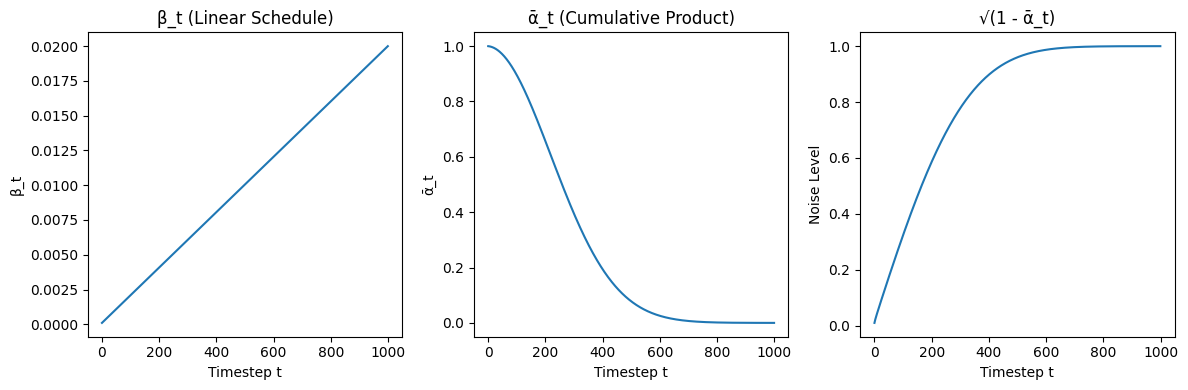

In [24]:


plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(scheduler.betas.cpu().numpy())
plt.title('β_t (Linear Schedule)')
plt.xlabel('Timestep t')
plt.ylabel('β_t')

plt.subplot(1, 3, 2)
plt.plot(scheduler.alphas_cumprod.cpu().numpy())
plt.title('ᾱ_t (Cumulative Product)')
plt.xlabel('Timestep t')
plt.ylabel('ᾱ_t')

plt.subplot(1, 3, 3)
plt.plot(scheduler.sqrt_one_minus_alphas_cumprod.cpu().numpy())
plt.title('√(1 - ᾱ_t)')
plt.xlabel('Timestep t')
plt.ylabel('Noise Level')

plt.tight_layout()
plt.show()



## 1.3 Visualize Forward Diffusion Process

Demonstrating how noise is progressively added to an image.

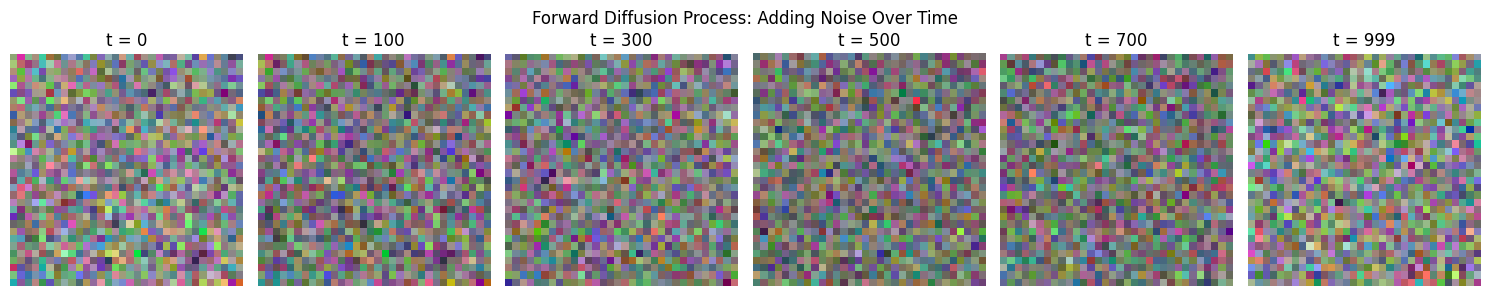

✅ Forward process visualization complete!


In [25]:
def visualize_forward_process(scheduler, img_size=(3, 32, 32), timesteps_to_show=[0, 100, 300, 500, 700, 999]):
    """
    Visualize the forward diffusion process at various timesteps.
    """
    # Create a sample image (random or could load a real one)
    x_0 = torch.randn(1, *img_size, device=device) * 0.5  # Start with some pattern

    fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(15, 3))

    for idx, t in enumerate(timesteps_to_show):
        t_tensor = torch.tensor([t], device=device)
        x_t, _ = scheduler.perturb_input(x_0, t_tensor)

        # Convert to displayable format
        img = x_t[0].permute(1, 2, 0).cpu().numpy()
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        axes[idx].imshow(img)
        axes[idx].set_title(f't = {t}')
        axes[idx].axis('off')

    plt.suptitle('Forward Diffusion Process: Adding Noise Over Time')
    plt.tight_layout()
    plt.show()

# Visualize
visualize_forward_process(scheduler)
print("✅ Forward process visualization complete!")

## 1.4 U-Net Architecture for Noise Prediction

A complete U-Net implementation with:
- Sinusoidal time embeddings
- Residual blocks
- Attention mechanisms
- Skip connections

In [7]:
class SinusoidalPositionEmbeddings(nn.Module):
    """
    Sinusoidal position embeddings for timestep encoding.
    Similar to the positional encoding in Transformers.
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings


class ResidualBlock(nn.Module):
    """
    Residual block with time embedding injection.
    """
    def __init__(self, in_channels, out_channels, time_emb_dim, up=False):
        super().__init__()

        self.time_mlp = nn.Linear(time_emb_dim, out_channels)

        if up:
            self.conv1 = nn.Conv2d(2 * in_channels, out_channels, 3, padding=1)
            self.transform = nn.ConvTranspose2d(out_channels, out_channels, 4, 2, 1)
        else:
            self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
            self.transform = nn.Conv2d(out_channels, out_channels, 4, 2, 1)

        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()

    def forward(self, x, t):
        # First convolution
        h = self.bn1(self.relu(self.conv1(x)))

        # Add time embedding
        time_emb = self.relu(self.time_mlp(t))
        time_emb = time_emb[(...,) + (None,) * 2]  # Expand dims for broadcasting
        h = h + time_emb

        # Second convolution
        h = self.bn2(self.relu(self.conv2(h)))

        # Downsample or upsample
        return self.transform(h)


class SelfAttention(nn.Module):
    """
    Self-attention mechanism for feature maps.
    """
    def __init__(self, channels):
        super().__init__()
        self.channels = channels
        self.mha = nn.MultiheadAttention(channels, 4, batch_first=True)
        self.ln = nn.LayerNorm([channels])
        self.ff = nn.Sequential(
            nn.LayerNorm([channels]),
            nn.Linear(channels, channels),
            nn.GELU(),
            nn.Linear(channels, channels),
        )

    def forward(self, x):
        size = x.shape[-1]
        x = x.view(-1, self.channels, size * size).transpose(1, 2)
        x_ln = self.ln(x)
        attention_value, _ = self.mha(x_ln, x_ln, x_ln)
        attention_value = attention_value + x
        attention_value = self.ff(attention_value) + attention_value
        return attention_value.transpose(1, 2).view(-1, self.channels, size, size)


class UNet(nn.Module):
    """
    U-Net architecture for DDPM noise prediction.

    Architecture:
    - Encoder: Downsampling path with residual blocks
    - Bottleneck: Self-attention + residual blocks
    - Decoder: Upsampling path with skip connections
    """
    def __init__(self, c_in=3, c_out=3, time_dim=256, base_channels=64):
        super().__init__()

        # Time embedding
        self.time_dim = time_dim
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.ReLU()
        )

        # Initial convolution
        self.inc = nn.Conv2d(c_in, base_channels, kernel_size=3, padding=1)

        # Downsampling path
        self.down1 = ResidualBlock(base_channels, base_channels * 2, time_dim)
        self.sa1 = SelfAttention(base_channels * 2)
        self.down2 = ResidualBlock(base_channels * 2, base_channels * 4, time_dim)
        self.sa2 = SelfAttention(base_channels * 4)
        self.down3 = ResidualBlock(base_channels * 4, base_channels * 4, time_dim)
        self.sa3 = SelfAttention(base_channels * 4)

        # Bottleneck
        self.bot1 = nn.Conv2d(base_channels * 4, base_channels * 8, 3, padding=1)
        self.bot2 = nn.Conv2d(base_channels * 8, base_channels * 8, 3, padding=1)
        self.bot3 = nn.Conv2d(base_channels * 8, base_channels * 4, 3, padding=1)

        # Upsampling path
        self.up1 = ResidualBlock(base_channels * 4, base_channels * 2, time_dim, up=True)
        self.sa4 = SelfAttention(base_channels * 2)
        self.up2 = ResidualBlock(base_channels * 2, base_channels, time_dim, up=True)
        self.sa5 = SelfAttention(base_channels)
        self.up3 = ResidualBlock(base_channels, base_channels, time_dim, up=True)
        self.sa6 = SelfAttention(base_channels)

        # Output
        self.outc = nn.Conv2d(base_channels, c_out, kernel_size=1)

    def forward(self, x, t):
        # Time embedding
        t = self.time_mlp(t)

        # Initial convolution
        x1 = self.inc(x)

        # Downsampling
        x2 = self.down1(x1, t)
        x2 = self.sa1(x2)
        x3 = self.down2(x2, t)
        x3 = self.sa2(x3)
        x4 = self.down3(x3, t)
        x4 = self.sa3(x4)

        # Bottleneck
        x4 = F.relu(self.bot1(x4))
        x4 = F.relu(self.bot2(x4))
        x4 = F.relu(self.bot3(x4))

        # Upsampling with skip connections
        x = self.up1(torch.cat([x4, x4], dim=1), t)
        x = self.sa4(x)
        x = self.up2(torch.cat([x, x3[:, :x.shape[1]]], dim=1), t)
        x = self.sa5(x)
        x = self.up3(torch.cat([x, x2[:, :x.shape[1]]], dim=1), t)
        x = self.sa6(x)

        # Output
        output = self.outc(x)
        return output



In [8]:

test_model = UNet(c_in=3, c_out=3, time_dim=256, base_channels=32).to(device)
test_x = torch.randn(2, 3, 32, 32, device=device)
test_t = torch.randint(0, 1000, (2,), device=device)
test_out = test_model(test_x, test_t)


In [9]:
print(f"Input shape: {test_x.shape}")
print(f"Output shape: {test_out.shape}")
print(f"Model parameters: {sum(p.numel() for p in test_model.parameters()):,}")

Input shape: torch.Size([2, 3, 32, 32])
Output shape: torch.Size([2, 3, 32, 32])
Model parameters: 3,145,443


## 1.5 Dataset Preparation

Load a dataset for training. We'll use CIFAR-10 for demonstration.

In [16]:
# Hyperparameters for DDPM training
DDPM_CONFIG = {
    'image_size': 32,
    'channels': 3,
    'batch_size': 128,
    'learning_rate': 1e-4,
    'num_epochs': 20,  # Increase for better results
    'num_timesteps': 1000,
    'beta_start': 0.0001,
    'beta_end': 0.02,
}


In [17]:

# Image transformations
transform = transforms.Compose([
    transforms.Resize(DDPM_CONFIG['image_size']),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # Normalize to [-1, 1]
])



In [18]:
# Load CIFAR-10 dataset
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)


Batch shape: torch.Size([128, 3, 32, 32])


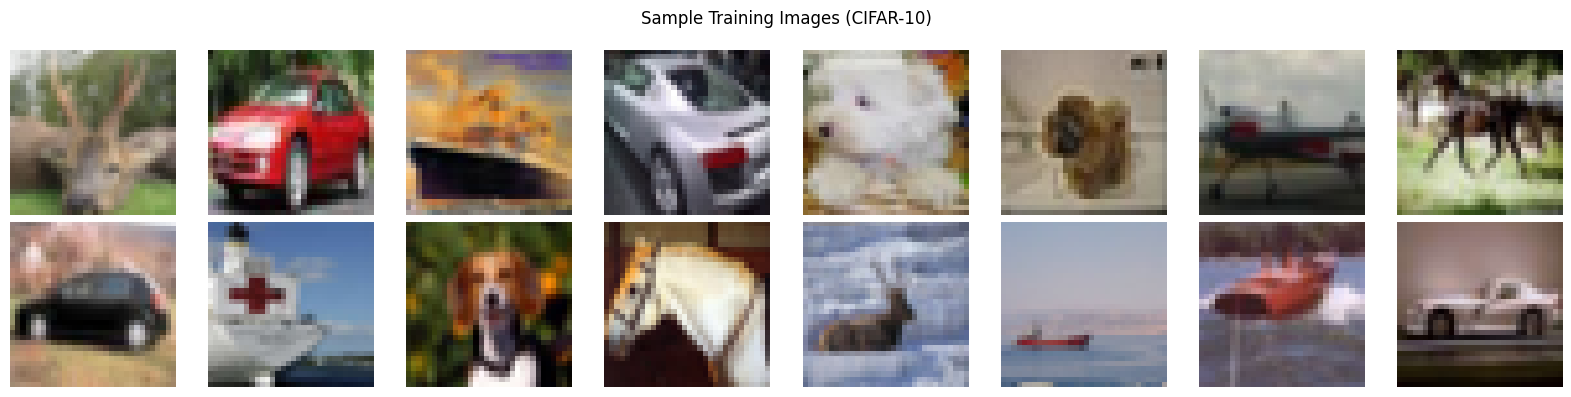

In [19]:

train_loader = DataLoader(
    train_dataset,
    batch_size=DDPM_CONFIG['batch_size'],
    shuffle=True,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

sample_batch, labels = next(iter(train_loader))
print(f"Batch shape: {sample_batch.shape}")

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    img = sample_batch[i].permute(1, 2, 0).numpy()
    img = (img + 1) / 2
    ax.imshow(img)
    ax.axis('off')
plt.suptitle('Sample Training Images (CIFAR-10)')
plt.tight_layout()
plt.show()

## 1.6 Step 3: DDPM Training Loop

The training loop implements:
1. Sample random timesteps for each image in the batch
2. Add noise to images using the forward process
3. Predict the noise with the U-Net
4. Compute MSE loss between predicted and actual noise
5. Backpropagate and update weights

In [20]:
class DDPMTrainer:
    """
    Complete DDPM Training Pipeline
    """
    def __init__(self, model, scheduler, optimizer, device):
        self.model = model
        self.scheduler = scheduler
        self.optimizer = optimizer
        self.device = device
        self.loss_history = []

    def train_step(self, x_0):
        """
        Single training step for DDPM.

        Args:
            x_0: Batch of clean images [B, C, H, W]

        Returns:
            loss: MSE loss value
        """
        self.model.train()
        batch_size = x_0.shape[0]

        # Step 1: Sample random timesteps for each image
        t = torch.randint(0, self.scheduler.num_timesteps, (batch_size,), device=self.device)

        # Step 2: Add noise to images (Forward Process)
        x_t, noise = self.scheduler.perturb_input(x_0, t)

        # Step 3: Predict noise with the model
        noise_pred = self.model(x_t, t)

        # Step 4: Compute MSE loss
        loss = F.mse_loss(noise_pred, noise)

        # Step 5: Backpropagation
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)  # Gradient clipping
        self.optimizer.step()

        return loss.item()

    def train_epoch(self, dataloader, epoch):
        """
        Train for one epoch.
        """
        epoch_loss = 0
        pbar = tqdm(dataloader, desc=f"Epoch {epoch}")

        for batch_idx, (images, _) in enumerate(pbar):
            images = images.to(self.device)
            loss = self.train_step(images)
            epoch_loss += loss

            # Update progress bar
            pbar.set_postfix({'loss': f'{loss:.4f}'})

        avg_loss = epoch_loss / len(dataloader)
        self.loss_history.append(avg_loss)
        return avg_loss

    def train(self, dataloader, num_epochs, save_path=None):
        """
        Full training loop.
        """
        print(f"Starting training for {num_epochs} epochs...")

        for epoch in range(1, num_epochs + 1):
            avg_loss = self.train_epoch(dataloader, epoch)
            print(f"Epoch {epoch}/{num_epochs} - Average Loss: {avg_loss:.4f}")

            # Save checkpoint periodically
            if save_path and epoch % 5 == 0:
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': self.optimizer.state_dict(),
                    'loss': avg_loss,
                }, f"{save_path}/checkpoint_epoch_{epoch}.pt")

        print("✅ Training complete!")
        return self.loss_history

    def plot_loss(self, save_path=None):
        """Plot training loss curve (and optionally save it for the report)."""
        plt.figure(figsize=(10, 4))
        plt.plot(self.loss_history)
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('DDPM Training Loss')
        plt.grid(True)

        if save_path is None and 'REPORT_FIG_DIR' in globals():
            save_path = REPORT_FIG_DIR / "ddpm_training_loss.png"
        if save_path is not None:
            save_path = Path(save_path)
            save_path.parent.mkdir(parents=True, exist_ok=True)
            plt.savefig(save_path, dpi=200, bbox_inches="tight")
            print(f"✅ Saved: {save_path}")

        plt.show()

In [21]:
ddpm_model = UNet(
    c_in=DDPM_CONFIG['channels'],
    c_out=DDPM_CONFIG['channels'],
    time_dim=256,
    base_channels=64
).to(device)

ddpm_scheduler = DDPMScheduler(
    num_timesteps=DDPM_CONFIG['num_timesteps'],
    beta_start=DDPM_CONFIG['beta_start'],
    beta_end=DDPM_CONFIG['beta_end'],
    device=device
)

optimizer = torch.optim.AdamW(ddpm_model.parameters(), lr=DDPM_CONFIG['learning_rate'])

trainer = DDPMTrainer(ddpm_model, ddpm_scheduler, optimizer, device)

print(f"Model parameters: {sum(p.numel() for p in ddpm_model.parameters()):,}")


Model parameters: 12,135,619


Starting training for 10 epochs...


Epoch 1: 100%|██████████| 391/391 [03:08<00:00,  2.07it/s, loss=0.0731]


Epoch 1/10 - Average Loss: 0.1811


Epoch 2: 100%|██████████| 391/391 [03:09<00:00,  2.06it/s, loss=0.0513]


Epoch 2/10 - Average Loss: 0.0606


...

Epoch 8/10 - Average Loss: 0.0425


Epoch 9: 100%|██████████| 391/391 [03:09<00:00,  2.06it/s, loss=0.0474]


Epoch 9/10 - Average Loss: 0.0423


Epoch 10: 100%|██████████| 391/391 [03:09<00:00,  2.06it/s, loss=0.0484]


Epoch 10/10 - Average Loss: 0.0415
✅ Training complete!
✅ Saved: ../report/En_report/figures/ddpm_training_loss.png


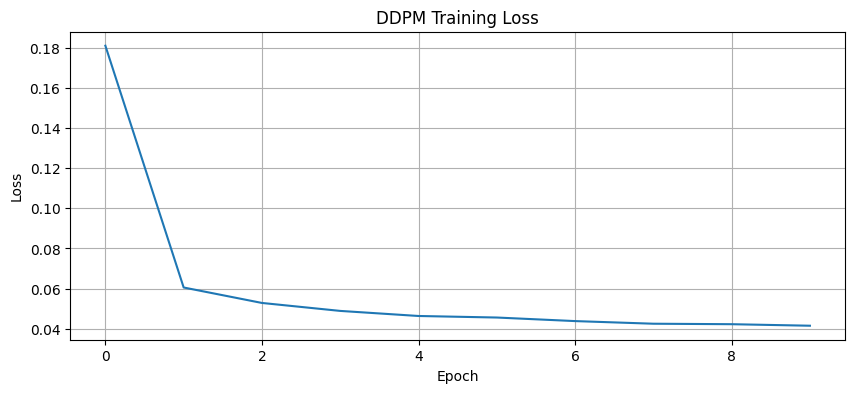

In [22]:
DEMO_EPOCHS = 10  # Change to DDPM_CONFIG['num_epochs'] for full training

loss_history = trainer.train(train_loader, num_epochs=DEMO_EPOCHS)
trainer.plot_loss(save_path=REPORT_FIG_DIR / "ddpm_training_loss.png")

## 1.7 Step 4: DDPM and DDIM Sampling

Implementing both sampling algorithms:
- **DDPM Sampling**: Stochastic, requires all T timesteps
- **DDIM Sampling**: Deterministic (when η=0), can skip timesteps for faster generation

In [40]:
class DDPMSampler:
    """
    DDPM Sampling: Stochastic reverse process.

    Algorithm:
    For t = T, T-1, ..., 1:
        z ~ N(0, I) if t > 1 else z = 0
        x_{t-1} = (1/√α_t)(x_t - (1-α_t)/√(1-ᾱ_t) * ε_θ(x_t, t)) + σ_t * z
    """
    def __init__(self, model, scheduler, device):
        self.model = model
        self.scheduler = scheduler
        self.device = device

    @torch.no_grad()
    def sample(self, batch_size, img_size=(3, 32, 32), show_progress=True):
        """
        Generate samples using DDPM reverse process.

        Args:
            batch_size: Number of images to generate
            img_size: Size of images (C, H, W)
            show_progress: Whether to show progress bar

        Returns:
            Generated images [B, C, H, W]
        """
        self.model.eval()

        # Start from pure Gaussian noise
        x = torch.randn(batch_size, *img_size, device=self.device)

        # Store intermediate samples for visualization
        intermediates = [x.clone()]

        # Reverse process: from T to 1
        timesteps = reversed(range(self.scheduler.num_timesteps))
        if show_progress:
            timesteps = tqdm(timesteps, desc="DDPM Sampling", total=self.scheduler.num_timesteps)

        for t in timesteps:
            t_tensor = torch.full((batch_size,), t, device=self.device, dtype=torch.long)

            # Predict noise
            noise_pred = self.model(x, t_tensor)

            # Get coefficients
            alpha = self.scheduler.alphas[t]
            alpha_cumprod = self.scheduler.alphas_cumprod[t]
            beta = self.scheduler.betas[t]

            # Sample noise for stochastic process (except at t=0)
            if t > 0:
                noise = torch.randn_like(x)
            else:
                noise = torch.zeros_like(x)

            # DDPM update rule
            # x_{t-1} = (1/√α_t)(x_t - (1-α_t)/√(1-ᾱ_t) * ε_θ) + σ_t * z
            x = (1 / torch.sqrt(alpha)) * (
                x - ((1 - alpha) / torch.sqrt(1 - alpha_cumprod)) * noise_pred
            ) + torch.sqrt(beta) * noise

            # Store intermediate (every 100 steps)
            if t % 100 == 0:
                intermediates.append(x.clone())

        return x, intermediates


class DDIMSampler:
    """
    DDIM Sampling: Deterministic (η=0) or semi-stochastic reverse process.
    Can skip timesteps for faster generation.

    Key difference from DDPM:
    - Non-Markovian process
    - Deterministic when η=0
    - Can use fewer steps (e.g., 50 instead of 1000)
    """
    def __init__(self, model, scheduler, device):
        self.model = model
        self.scheduler = scheduler
        self.device = device

    @torch.no_grad()
    def sample(self, batch_size, img_size=(3, 32, 32), num_inference_steps=50, eta=0.0, show_progress=True):
        """
        Generate samples using DDIM reverse process.

        Args:
            batch_size: Number of images to generate
            img_size: Size of images (C, H, W)
            num_inference_steps: Number of denoising steps (can be << T)
            eta: Controls stochasticity (0 = deterministic, 1 = DDPM-like)
            show_progress: Whether to show progress bar

        Returns:
            Generated images [B, C, H, W]
        """
        self.model.eval()

        # Create timestep schedule (skip steps for faster sampling)
        step_ratio = self.scheduler.num_timesteps // num_inference_steps
        timesteps = np.arange(0, self.scheduler.num_timesteps, step_ratio)[::-1].copy()

        # Start from pure Gaussian noise
        x = torch.randn(batch_size, *img_size, device=self.device)

        intermediates = [x.clone()]

        if show_progress:
            timesteps_iter = tqdm(enumerate(timesteps), desc="DDIM Sampling", total=len(timesteps))
        else:
            timesteps_iter = enumerate(timesteps)

        for i, t in timesteps_iter:
            t_tensor = torch.full((batch_size,), t, device=self.device, dtype=torch.long)

            # Predict noise
            noise_pred = self.model(x, t_tensor)

            # Get alpha values
            alpha_cumprod_t = self.scheduler.alphas_cumprod[t]

            # Get alpha for previous timestep
            if i < len(timesteps) - 1:
                t_prev = timesteps[i + 1]
                alpha_cumprod_t_prev = self.scheduler.alphas_cumprod[t_prev]
            else:
                alpha_cumprod_t_prev = torch.tensor(1.0, device=self.device)

            # Predict x_0 from x_t and noise prediction
            # x_0 = (x_t - √(1-ᾱ_t) * ε) / √(ᾱ_t)
            pred_x0 = (x - torch.sqrt(1 - alpha_cumprod_t) * noise_pred) / torch.sqrt(alpha_cumprod_t)

            # Optionally clip x_0 to [-1, 1]
            pred_x0 = torch.clamp(pred_x0, -1, 1)

            # Compute direction pointing to x_t
            # "direction" = √(1-ᾱ_{t-1} - σ²) * ε_θ
            sigma = eta * torch.sqrt((1 - alpha_cumprod_t_prev) / (1 - alpha_cumprod_t)) * \
                    torch.sqrt(1 - alpha_cumprod_t / alpha_cumprod_t_prev)

            direction = torch.sqrt(1 - alpha_cumprod_t_prev - sigma**2) * noise_pred

            # Sample noise
            if eta > 0 and i < len(timesteps) - 1:
                noise = torch.randn_like(x)
            else:
                noise = torch.zeros_like(x)

            # DDIM update rule
            # x_{t-1} = √(ᾱ_{t-1}) * pred_x0 + direction + σ * noise
            x = torch.sqrt(alpha_cumprod_t_prev) * pred_x0 + direction + sigma * noise

            # Store intermediate
            if i % 10 == 0:
                intermediates.append(x.clone())

        return x, intermediates



In [24]:

ddpm_sampler = DDPMSampler(ddpm_model, ddpm_scheduler, device)
ddim_sampler = DDIMSampler(ddpm_model, ddpm_scheduler, device)



In [25]:
print("Generating samples with DDPM (1000 steps)...")
ddpm_samples, ddpm_intermediates = ddpm_sampler.sample(batch_size=16)


Generating samples with DDPM (1000 steps)...


DDPM Sampling: 100%|██████████| 1000/1000 [00:21<00:00, 47.02it/s]


In [26]:
print("\nGenerating samples with DDIM (50 steps)...")
ddim_samples, ddim_intermediates = ddim_sampler.sample(batch_size=16, num_inference_steps=50, eta=0.0)



Generating samples with DDIM (50 steps)...


DDIM Sampling: 100%|██████████| 50/50 [00:01<00:00, 43.33it/s]


In [27]:
def visualize_samples(samples, title="Generated Samples", save_path=None):
    """Helper function to visualize a batch of samples (and optionally save a grid)."""
    fig, axes = plt.subplots(2, 8, figsize=(16, 4))
    for i, ax in enumerate(axes.flat):
        if i < len(samples):
            img = samples[i].permute(1, 2, 0).cpu().numpy()
            img = (img + 1) / 2  # Denormalize from [-1, 1] to [0, 1]
            img = np.clip(img, 0, 1)
            ax.imshow(img)
        ax.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"✅ Saved: {save_path}")
    plt.show()

✅ Saved: ../report/En_report/figures/ddpm_samples_grid.png


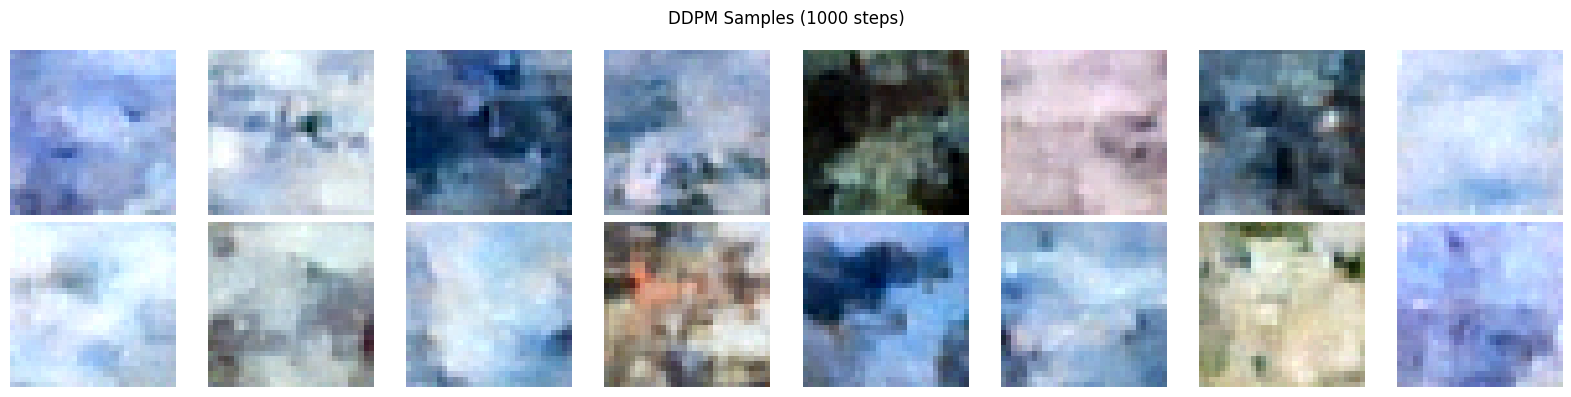

✅ Saved: ../report/En_report/figures/ddim_samples_grid.png


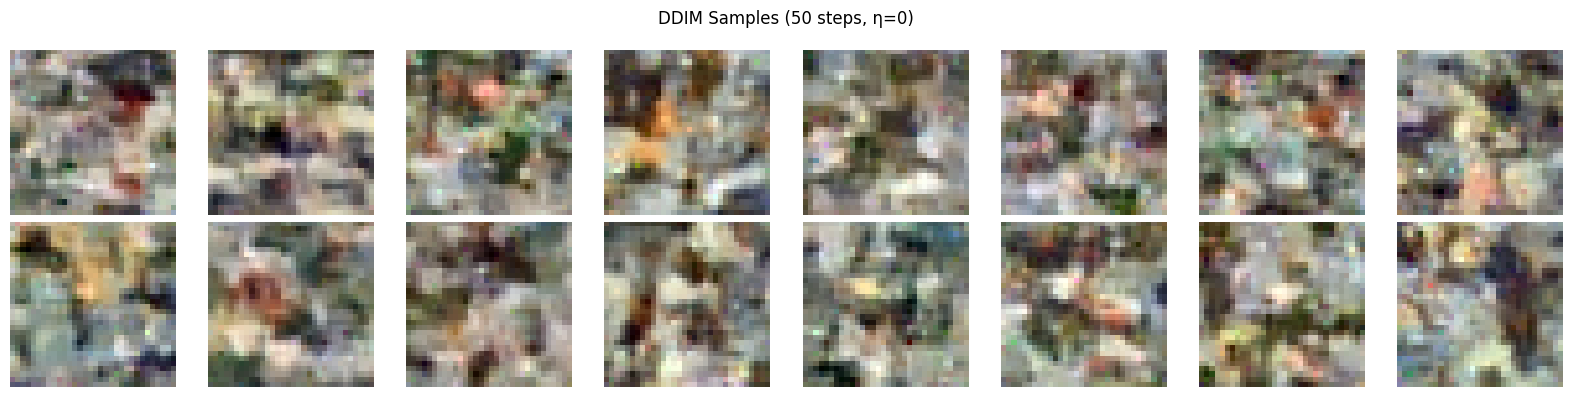

In [28]:
visualize_samples(ddpm_samples, "DDPM Samples (1000 steps)", save_path=REPORT_FIG_DIR / "ddpm_samples_grid.png")
visualize_samples(ddim_samples, "DDIM Samples (50 steps, η=0)", save_path=REPORT_FIG_DIR / "ddim_samples_grid.png")

In [29]:
def visualize_denoising_process(intermediates, title="Denoising Process"):
    """Visualize the progressive denoising."""
    n_steps = min(len(intermediates), 10)
    fig, axes = plt.subplots(1, n_steps, figsize=(2 * n_steps, 2))

    step_indices = np.linspace(0, len(intermediates) - 1, n_steps, dtype=int)

    for idx, step_idx in enumerate(step_indices):
        img = intermediates[step_idx][0].permute(1, 2, 0).cpu().numpy()
        img = (img + 1) / 2
        img = np.clip(img, 0, 1)
        axes[idx].imshow(img)
        axes[idx].set_title(f"Step {step_idx}")
        axes[idx].axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()



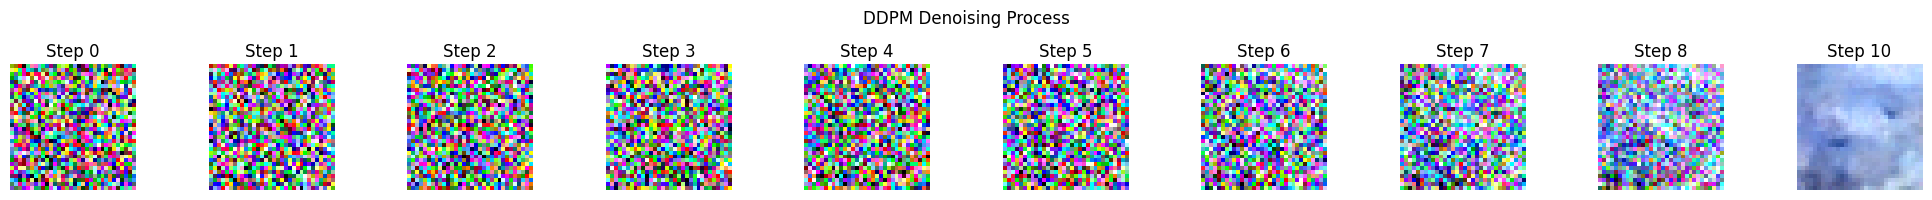

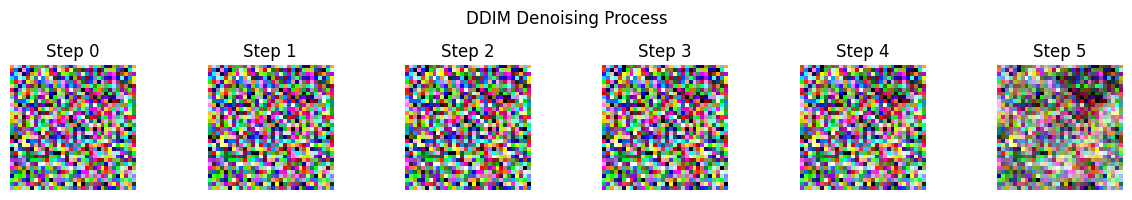

In [30]:
visualize_denoising_process(ddpm_intermediates, "DDPM Denoising Process")
visualize_denoising_process(ddim_intermediates, "DDIM Denoising Process")

---
# Part 2: Stable Diffusion & DreamBooth

## 2.1 Introduction

**Stable Diffusion** performs diffusion in latent space rather than pixel space, significantly reducing computational cost.

Key components:
1. **VAE**: Encodes images to latent space and decodes back
2. **U-Net**: Denoises in latent space
3. **Text Encoder (CLIP)**: Converts text prompts to embeddings

**DreamBooth** is a fine-tuning technique that teaches the model a specific subject using only 3-5 images.

---

In [26]:
try:
    from diffusers import (
        StableDiffusionPipeline,
        DDPMScheduler as DiffusersDDPMScheduler,
        UNet2DConditionModel,
        AutoencoderKL
    )
    from transformers import CLIPTextModel, CLIPTokenizer
    from peft import LoraConfig, get_peft_model
    DIFFUSERS_AVAILABLE = True
    print("✅ Diffusers library available!")
except ImportError:
    DIFFUSERS_AVAILABLE = False
    print("⚠️ Diffusers not installed. Run: pip install diffusers transformers peft accelerate")
    print("   DreamBooth section will use mock implementations for demonstration.")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


✅ Diffusers library available!


## 2.2 Step 1 & 2: DreamBooth Dataset Class

Complete implementation of the dataset for DreamBooth training with Prior Preservation.

In [27]:
class DreamBoothDataset(Dataset):
    """
    DreamBooth Dataset for fine-tuning Stable Diffusion.

    Features:
    - Loads instance images (your specific subject, e.g., "sks dog")
    - Optionally loads class images for Prior Preservation (generic dogs)
    - Handles image preprocessing and prompt tokenization

    Args:
        instance_data_root: Path to folder with instance images
        instance_prompt: Prompt describing the instance (e.g., "a photo of sks dog")
        tokenizer: CLIP tokenizer for text encoding
        class_data_root: Optional path to class images for prior preservation
        class_prompt: Generic prompt (e.g., "a photo of a dog")
        size: Image size (default 512 for Stable Diffusion)
        center_crop: Whether to center crop images
    """
    def __init__(
        self,
        instance_data_root,
        instance_prompt,
        tokenizer,
        class_data_root=None,
        class_prompt=None,
        size=512,
        center_crop=False,
    ):
        self.size = size
        self.center_crop = center_crop
        self.tokenizer = tokenizer
        self.instance_prompt = instance_prompt
        self.class_prompt = class_prompt

        # Load instance images
        self.instance_data_root = Path(instance_data_root)
        if not self.instance_data_root.exists():
            raise ValueError(f"Instance data root doesn't exist: {instance_data_root}")

        # Get all image files
        image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.webp']
        self.instance_images_path = []
        for ext in image_extensions:
            self.instance_images_path.extend(list(self.instance_data_root.glob(ext)))

        self.num_instance_images = len(self.instance_images_path)
        if self.num_instance_images == 0:
            raise ValueError(f"No images found in {instance_data_root}")

        print(f"Found {self.num_instance_images} instance images")

        # Load class images (for Prior Preservation)
        self.class_data_root = None
        self.class_images_path = []
        self.num_class_images = 0

        if class_data_root is not None:
            self.class_data_root = Path(class_data_root)
            self.class_data_root.mkdir(parents=True, exist_ok=True)

            for ext in image_extensions:
                self.class_images_path.extend(list(self.class_data_root.glob(ext)))

            self.num_class_images = len(self.class_images_path)
            print(f"Found {self.num_class_images} class images for prior preservation")

        # Dataset length
        self._length = max(self.num_class_images, self.num_instance_images)
        if self.num_class_images > 0:
            self._length = self.num_instance_images  # Match instance images

        # Image transformations
        self.image_transforms = transforms.Compose([
            transforms.Resize(size, interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.CenterCrop(size) if center_crop else transforms.RandomCrop(size),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),  # Normalize to [-1, 1]
        ])

    def __len__(self):
        return self._length

    def __getitem__(self, index):
        """
        Returns a dictionary containing:
        - instance_images: Preprocessed instance image tensor
        - instance_prompt_ids: Tokenized instance prompt
        - class_images (optional): Preprocessed class image tensor
        - class_prompt_ids (optional): Tokenized class prompt
        """
        example = {}

        # ==========================================
        # Step 1: Load and preprocess instance image
        # ==========================================
        instance_image_path = self.instance_images_path[index % self.num_instance_images]
        instance_image = Image.open(instance_image_path)

        # Convert to RGB if necessary
        if not instance_image.mode == "RGB":
            instance_image = instance_image.convert("RGB")

        # Apply transformations
        example["instance_images"] = self.image_transforms(instance_image)

        # ==========================================
        # Step 2: Tokenize instance prompt
        # ==========================================
        example["instance_prompt_ids"] = self.tokenizer(
            self.instance_prompt,
            padding="max_length",
            truncation=True,
            max_length=self.tokenizer.model_max_length,
            return_tensors="pt"
        ).input_ids.squeeze(0)

        # ==========================================
        # Step 3: Load class image (Prior Preservation)
        # ==========================================
        if self.class_data_root and self.num_class_images > 0:
            class_image_path = self.class_images_path[index % self.num_class_images]
            class_image = Image.open(class_image_path)

            if not class_image.mode == "RGB":
                class_image = class_image.convert("RGB")

            example["class_images"] = self.image_transforms(class_image)

            # Tokenize class prompt
            example["class_prompt_ids"] = self.tokenizer(
                self.class_prompt,
                padding="max_length",
                truncation=True,
                max_length=self.tokenizer.model_max_length,
                return_tensors="pt"
            ).input_ids.squeeze(0)

        return example


def collate_fn(examples, with_prior_preservation=True):
    """
    Custom collate function for DreamBooth dataloader.
    Combines instance and class examples for prior preservation loss.
    """
    input_ids = [example["instance_prompt_ids"] for example in examples]
    pixel_values = [example["instance_images"] for example in examples]

    # Add class images for prior preservation
    if with_prior_preservation and "class_images" in examples[0]:
        input_ids += [example["class_prompt_ids"] for example in examples]
        pixel_values += [example["class_images"] for example in examples]

    pixel_values = torch.stack(pixel_values)
    input_ids = torch.stack(input_ids)

    return {
        "input_ids": input_ids,
        "pixel_values": pixel_values,
    }




## 2.3 Step 3: Generate Class Images (Bonus)

Using the pre-trained Stable Diffusion model to generate class images for prior preservation.

In [28]:
def generate_class_images(
    class_prompt,
    class_data_root,
    num_class_images=100,
    model_id="runwayml/stable-diffusion-v1-5",
    batch_size=4,
    device="cuda"
):
    """
    Step 3 (Bonus): Generate class images for prior preservation.

    Uses the pre-trained Stable Diffusion model to generate generic images
    (e.g., regular dogs) to prevent the model from forgetting.

    Args:
        class_prompt: Generic prompt (e.g., "a photo of a dog")
        class_data_root: Path to save generated images
        num_class_images: Number of images to generate
        model_id: HuggingFace model ID
        batch_size: Batch size for generation
        device: Device to use
    """
    if not DIFFUSERS_AVAILABLE:
        print("⚠️ Diffusers not available. Skipping class image generation.")
        return

    class_data_root = Path(class_data_root)
    class_data_root.mkdir(parents=True, exist_ok=True)

    # Check how many images already exist
    existing_images = list(class_data_root.glob("*.png"))
    if len(existing_images) >= num_class_images:
        print(f"Already have {len(existing_images)} class images. Skipping generation.")
        return

    print(f"Generating {num_class_images - len(existing_images)} class images...")

    # Load the pipeline
    pipeline = StableDiffusionPipeline.from_pretrained(
        model_id,
        torch_dtype=torch.float16 if device == "cuda" else torch.float32,
        safety_checker=None,
    ).to(device)

    pipeline.set_progress_bar_config(disable=True)

    # Generate images
    num_to_generate = num_class_images - len(existing_images)
    start_idx = len(existing_images)

    for i in tqdm(range(0, num_to_generate, batch_size), desc="Generating class images"):
        batch_count = min(batch_size, num_to_generate - i)

        images = pipeline(
            [class_prompt] * batch_count,
            num_inference_steps=50,
            guidance_scale=7.5,
        ).images

        for j, image in enumerate(images):
            image.save(class_data_root / f"class_image_{start_idx + i + j:04d}.png")

    print(f"✅ Generated {num_to_generate} class images in {class_data_root}")

    # Clear memory
    del pipeline
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# Example usage (uncomment to run):
generate_class_images(
    class_prompt="a photo of a dog",
    class_data_root="./class_data",
    num_class_images=100
)



Generating 100 class images...


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
Generating class images: 100%|██████████| 25/25 [11:56<00:00, 28.67s/it]

✅ Generated 100 class images in class_data


## 2.4 Step 4: DreamBooth Training Loop with LoRA

Complete training loop for DreamBooth with:
- LoRA (Low-Rank Adaptation) for efficient fine-tuning
- Prior preservation loss to prevent catastrophic forgetting
- Mixed precision training support

In [29]:
class DreamBoothTrainer:
    """
    DreamBooth Trainer with LoRA support.

    Implements the full training pipeline:
    1. Encode images to latent space using VAE
    2. Add noise (forward diffusion)
    3. Predict noise with U-Net conditioned on text
    4. Compute loss (with optional prior preservation)
    5. Update only LoRA weights
    """
    def __init__(
        self,
        model_id="runwayml/stable-diffusion-v1-5",
        lora_rank=4,
        learning_rate=1e-4,
        prior_preservation=True,
        prior_loss_weight=1.0,
        device="cuda",
    ):
        self.device = device
        self.prior_preservation = prior_preservation
        self.prior_loss_weight = prior_loss_weight
        self.loss_history = []

        if not DIFFUSERS_AVAILABLE:
            print("⚠️ Diffusers not available. Using mock implementation.")
            self._setup_mock()
            return

        print(f"Loading Stable Diffusion model: {model_id}")

        # Load tokenizer
        self.tokenizer = CLIPTokenizer.from_pretrained(
            model_id, subfolder="tokenizer"
        )

        # Load text encoder
        self.text_encoder = CLIPTextModel.from_pretrained(
            model_id, subfolder="text_encoder"
        ).to(device)
        self.text_encoder.requires_grad_(False)  # Freeze text encoder

        # Load VAE
        self.vae = AutoencoderKL.from_pretrained(
            model_id, subfolder="vae"
        ).to(device)
        self.vae.requires_grad_(False)  # Freeze VAE

        # Load U-Net
        self.unet = UNet2DConditionModel.from_pretrained(
            model_id, subfolder="unet"
        ).to(device)

        # Apply LoRA to U-Net
        print(f"Applying LoRA with rank {lora_rank}...")
        lora_config = LoraConfig(
            r=lora_rank,
            lora_alpha=lora_rank,
            init_lora_weights="gaussian",
            target_modules=["to_k", "to_q", "to_v", "to_out.0"],
        )
        self.unet = get_peft_model(self.unet, lora_config)
        self.unet.print_trainable_parameters()

        # Load scheduler
        self.noise_scheduler = DiffusersDDPMScheduler.from_pretrained(
            model_id, subfolder="scheduler"
        )

        # Optimizer (only LoRA parameters)
        self.optimizer = torch.optim.AdamW(
            self.unet.parameters(),
            lr=learning_rate,
            weight_decay=1e-2,
        )

        # Mixed precision scaler
        self.scaler = torch.cuda.amp.GradScaler() if device == "cuda" else None

        # VAE scaling factor
        self.vae_scale_factor = 0.18215

        print("✅ DreamBooth trainer initialized!")

    def _setup_mock(self):
        """Setup mock components when diffusers is not available."""
        self.tokenizer = None
        self.text_encoder = None
        self.vae = None
        self.unet = None
        self.noise_scheduler = None
        self.optimizer = None
        self.scaler = None

    def encode_images(self, images):
        """Encode images to latent space using VAE."""
        with torch.no_grad():
            latents = self.vae.encode(images).latent_dist.sample()
            latents = latents * self.vae_scale_factor
        return latents

    def encode_prompt(self, input_ids):
        """Encode text prompts using CLIP text encoder."""
        with torch.no_grad():
            encoder_hidden_states = self.text_encoder(input_ids)[0]
        return encoder_hidden_states

    def train_step(self, batch):
        """
        Single training step for DreamBooth.

        Args:
            batch: Dictionary with 'pixel_values' and 'input_ids'

        Returns:
            loss: Training loss value
        """
        if not DIFFUSERS_AVAILABLE:
            return 0.0

        self.unet.train()

        pixel_values = batch["pixel_values"].to(self.device)
        input_ids = batch["input_ids"].to(self.device)

        batch_size = pixel_values.shape[0]

        # Step 1: Encode images to latent space
        latents = self.encode_images(pixel_values)

        # Step 2: Sample noise
        noise = torch.randn_like(latents)

        # Step 3: Sample random timesteps
        timesteps = torch.randint(
            0, self.noise_scheduler.config.num_train_timesteps,
            (batch_size,), device=self.device
        ).long()

        # Step 4: Add noise (Forward process)
        noisy_latents = self.noise_scheduler.add_noise(latents, noise, timesteps)

        # Step 5: Encode text prompts
        encoder_hidden_states = self.encode_prompt(input_ids)

        # Step 6: Predict noise with U-Net
        with torch.cuda.amp.autocast(enabled=self.scaler is not None):
            noise_pred = self.unet(
                noisy_latents,
                timesteps,
                encoder_hidden_states
            ).sample

            # Step 7: Calculate loss
            if self.prior_preservation:
                # Split batch: first half is instance, second half is class
                noise_pred_instance, noise_pred_class = noise_pred.chunk(2)
                noise_instance, noise_class = noise.chunk(2)

                # Instance loss
                instance_loss = F.mse_loss(
                    noise_pred_instance, noise_instance, reduction="mean"
                )

                # Prior preservation loss
                prior_loss = F.mse_loss(
                    noise_pred_class, noise_class, reduction="mean"
                )

                loss = instance_loss + self.prior_loss_weight * prior_loss
            else:
                loss = F.mse_loss(noise_pred, noise, reduction="mean")

        # Step 8: Backpropagation
        self.optimizer.zero_grad()

        if self.scaler is not None:
            self.scaler.scale(loss).backward()
            self.scaler.step(self.optimizer)
            self.scaler.update()
        else:
            loss.backward()
            self.optimizer.step()

        return loss.item()

    def train(self, dataloader, num_epochs=100):
        """
        Full training loop.
        """
        if not DIFFUSERS_AVAILABLE:
            print("⚠️ Cannot train without diffusers library.")
            return

        print(f"Starting DreamBooth training for {num_epochs} epochs...")

        for epoch in range(1, num_epochs + 1):
            epoch_loss = 0
            pbar = tqdm(dataloader, desc=f"Epoch {epoch}")

            for batch in pbar:
                loss = self.train_step(batch)
                epoch_loss += loss
                pbar.set_postfix({'loss': f'{loss:.4f}'})

            avg_loss = epoch_loss / len(dataloader)
            self.loss_history.append(avg_loss)
            print(f"Epoch {epoch}/{num_epochs} - Loss: {avg_loss:.4f}")

        print("✅ DreamBooth training complete!")

    def save_lora_weights(self, save_path):
        """Save LoRA weights."""
        if not DIFFUSERS_AVAILABLE:
            return

        self.unet.save_pretrained(save_path)
        print(f"✅ LoRA weights saved to {save_path}")

    def plot_loss(self):
        """Plot training loss."""
        plt.figure(figsize=(10, 4))
        plt.plot(self.loss_history)
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('DreamBooth Training Loss')
        plt.grid(True)
        plt.show()




## 2.5 Step 5: Inference and Testing

Generate images with the fine-tuned model using different prompts and guidance scales.

In [30]:
class DreamBoothInference:
    """
    Inference pipeline for DreamBooth-trained models.
    """
    def __init__(
        self,
        model_id="runwayml/stable-diffusion-v1-5",
        lora_weights_path=None,
        device="cuda"
    ):
        self.device = device

        if not DIFFUSERS_AVAILABLE:
            print("⚠️ Diffusers not available for inference.")
            self.pipeline = None
            return

        print("Loading inference pipeline...")

        # Load pipeline
        self.pipeline = StableDiffusionPipeline.from_pretrained(
            model_id,
            torch_dtype=torch.float16 if device == "cuda" else torch.float32,
            safety_checker=None,
        ).to(device)

        # Load LoRA weights if provided
        if lora_weights_path:
            print(f"Loading LoRA weights from {lora_weights_path}")
            self.pipeline.unet.load_adapter(lora_weights_path)

        print("✅ Inference pipeline ready!")

    @torch.no_grad()
    def generate(
        self,
        prompt,
        negative_prompt="low quality, blurry, distorted",
        num_images=4,
        num_inference_steps=50,
        guidance_scale=7.5,
        seed=None
    ):
        """
        Generate images with the fine-tuned model.

        Args:
            prompt: Text prompt
            negative_prompt: Negative prompt for guidance
            num_images: Number of images to generate
            num_inference_steps: Denoising steps
            guidance_scale: CFG scale (higher = more prompt adherence)
            seed: Random seed for reproducibility

        Returns:
            List of PIL images
        """
        if self.pipeline is None:
            print("⚠️ Pipeline not available.")
            return []

        if seed is not None:
            generator = torch.Generator(device=self.device).manual_seed(seed)
        else:
            generator = None

        images = self.pipeline(
            prompt=[prompt] * num_images,
            negative_prompt=[negative_prompt] * num_images,
            num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale,
            generator=generator,
        ).images

        return images

    def visualize_guidance_scales(self, prompt, scales=[3.0, 5.0, 7.5, 10.0, 15.0]):
        """
        Compare different guidance scales for the same prompt.
        """
        if self.pipeline is None:
            return

        fig, axes = plt.subplots(1, len(scales), figsize=(4*len(scales), 4))

        for idx, scale in enumerate(scales):
            images = self.generate(prompt, num_images=1, guidance_scale=scale, seed=42)
            axes[idx].imshow(images[0])
            axes[idx].set_title(f'CFG Scale: {scale}')
            axes[idx].axis('off')

        plt.suptitle(f'Prompt: "{prompt}"')
        plt.tight_layout()
        plt.show()


# Example DreamBooth usage
DREAMBOOTH_CONFIG = {
    'instance_data_root': './instance_data',  # Put 3-5 images of your subject here
    'class_data_root': './class_data',         # Will be populated with generated class images
    'instance_prompt': 'a photo of sks dog',   # Replace 'sks' with your unique identifier
    'class_prompt': 'a photo of a dog',
    'num_class_images': 100,
    'learning_rate': 1e-4,
    'num_epochs': 100,
    'lora_rank': 4,
}



In [31]:
# Complete DreamBooth training example
# Uncomment and run when you have your instance images ready

"""
# Step 1: Prepare data folders
import os
os.makedirs(DREAMBOOTH_CONFIG['instance_data_root'], exist_ok=True)
os.makedirs(DREAMBOOTH_CONFIG['class_data_root'], exist_ok=True)

# Step 2: Generate class images (if not already done)
if DIFFUSERS_AVAILABLE:
    generate_class_images(
        class_prompt=DREAMBOOTH_CONFIG['class_prompt'],
        class_data_root=DREAMBOOTH_CONFIG['class_data_root'],
        num_class_images=DREAMBOOTH_CONFIG['num_class_images']
    )

# Step 3: Create dataset
if DIFFUSERS_AVAILABLE:
    tokenizer = CLIPTokenizer.from_pretrained(
        "runwayml/stable-diffusion-v1-5", subfolder="tokenizer"
    )

    train_dataset = DreamBoothDataset(
        instance_data_root=DREAMBOOTH_CONFIG['instance_data_root'],
        instance_prompt=DREAMBOOTH_CONFIG['instance_prompt'],
        tokenizer=tokenizer,
        class_data_root=DREAMBOOTH_CONFIG['class_data_root'],
        class_prompt=DREAMBOOTH_CONFIG['class_prompt'],
        size=512,
    )

    train_dataloader = DataLoader(
        train_dataset,
        batch_size=1,
        shuffle=True,
        collate_fn=lambda x: collate_fn(x, with_prior_preservation=True)
    )

# Step 4: Initialize trainer and train
if DIFFUSERS_AVAILABLE:
    dreambooth_trainer = DreamBoothTrainer(
        lora_rank=DREAMBOOTH_CONFIG['lora_rank'],
        learning_rate=DREAMBOOTH_CONFIG['learning_rate'],
        prior_preservation=True,
    )

    dreambooth_trainer.train(train_dataloader, num_epochs=DREAMBOOTH_CONFIG['num_epochs'])
    dreambooth_trainer.save_lora_weights('./dreambooth_lora')
    dreambooth_trainer.plot_loss()

# Step 5: Inference
if DIFFUSERS_AVAILABLE:
    inference = DreamBoothInference(lora_weights_path='./dreambooth_lora')

    test_prompts = [
        "a photo of sks dog on the moon",
        "a photo of sks dog in a bucket",
        "a photo of sks dog wearing a hat",
        "a painting of sks dog in the style of Van Gogh"
    ]

    for prompt in test_prompts:
        images = inference.generate(prompt, num_images=4)
        visualize_samples(torch.stack([
            transforms.ToTensor()(img) for img in images
        ]), title=prompt)
"""

print("DreamBooth training example commented out - uncomment when ready to train")

DreamBooth training example commented out - uncomment when ready to train


---
# Part 3: Flow Matching for Time Series

## 3.1 Introduction

**Flow Matching** is a continuous generative model that learns a time-dependent vector field $v_t(x)$ to transport samples from noise distribution $p_0$ to data distribution $p_1$.

Key equations:
- **ODE**: $\frac{dx}{dt} = v_t(x)$
- **Linear interpolation**: $x_t = (1-t)x_0 + tx_1$ where $x_0 \sim \mathcal{N}(0, I)$, $x_1 \sim p_{data}$
- **Target vector field**: $v_t(x_t) = x_1 - x_0$

This section implements Flow Matching for generating realistic financial time series (log-returns).

---

In [32]:
import pandas as pd
from scipy import stats
from scipy.ndimage import gaussian_filter1d

try:
    import yfinance as yf
    YFINANCE_AVAILABLE = True
except ImportError:
    YFINANCE_AVAILABLE = False
    print("⚠️ yfinance not installed. Run: pip install yfinance")
    print("   Using synthetic data for demonstration.")

print("✅ Part 3 imports ready!")

✅ Part 3 imports ready!


## 3.2 Data Preparation

Loading SPY (S&P 500 ETF) data and preparing log-returns for training.

In [33]:
class TimeSeriesDataset(Dataset):
    """
    Dataset for financial time series log-returns.
    """
    def __init__(self, data, seq_len=64):
        """
        Args:
            data: 1D numpy array of log-returns
            seq_len: Length of each sequence
        """
        self.seq_len = seq_len
        self.data = torch.tensor(data, dtype=torch.float32)

        # Create overlapping sequences
        num_sequences = len(data) - seq_len + 1
        self.sequences = torch.zeros(num_sequences, seq_len, 1)

        for i in range(num_sequences):
            self.sequences[i, :, 0] = self.data[i:i + seq_len]

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]


def load_spy_data(start_date="2010-01-01", end_date="2023-12-31", seq_len=64):
    """
    Load SPY data and prepare log-returns.

    Returns:
s         train_dataset, test_dataset, scaler_params (mean, std)
    """
    if YFINANCE_AVAILABLE:
        print(f"Downloading SPY data from {start_date} to {end_date}...")
        spy = yf.download("SPY", start=start_date, end=end_date, progress=False)

        # Robustly handle both single-level and MultiIndex columns
        cols = spy.columns
        if isinstance(cols, pd.MultiIndex):
            # Determine which level holds price field names (e.g., 'Close')
            if 'Price' in cols.names:
                price_level = cols.names.index('Price')
            else:
                price_level = 0
            price_names = cols.get_level_values(price_level)
            if 'Adj Close' in price_names:
                prices_series = spy.xs('Adj Close', axis=1, level=price_level)
            elif 'Close' in price_names:
                prices_series = spy.xs('Close', axis=1, level=price_level)
            else:
                raise ValueError(f"Could not find 'Adj Close' or 'Close' in MultiIndex columns: {cols}")
            # If multiple tickers, pick the first column
            if isinstance(prices_series, pd.DataFrame):
                prices = prices_series.iloc[:, 0].values
            else:
                prices = prices_series.values
        else:
            # Standard single-ticker DataFrame
            if 'Adj Close' in cols:
                prices = spy['Adj Close'].values
            elif 'Close' in cols:
                prices = spy['Close'].values
            else:
                raise ValueError(f"Could not find 'Adj Close' or 'Close' in columns: {list(cols)}")
    else:
        print("Using synthetic data (yfinance not available)...")
        # Generate synthetic price data that mimics market behavior
        np.random.seed(42)
        n_days = 3500  # ~14 years of trading days
        returns = np.random.normal(0.0003, 0.012, n_days)  # Mean ~7.5%/year, ~19% vol
        prices = 100 * np.exp(np.cumsum(returns))

    # Calculate log-returns
    log_returns = np.diff(np.log(prices))

    # Remove NaN values
    log_returns = log_returns[~np.isnan(log_returns)]

    # Standardize (global normalization)
    mean = np.mean(log_returns)
    std = np.std(log_returns)
    log_returns_normalized = (log_returns - mean) / std

    print(f"Data shape: {log_returns.shape}")
    print(f"Mean: {mean:.6f}, Std: {std:.6f}")

    # Chronological split (90% train, 10% test)
    split_idx = int(len(log_returns_normalized) * 0.9)
    train_data = log_returns_normalized[:split_idx]
    test_data = log_returns_normalized[split_idx:]

    print(f"Train samples: {len(train_data)}, Test samples: {len(test_data)}")

    # Create datasets
    train_dataset = TimeSeriesDataset(train_data, seq_len=seq_len)
    test_dataset = TimeSeriesDataset(test_data, seq_len=seq_len)

    print(f"Train sequences: {len(train_dataset)}, Test sequences: {len(test_dataset)}")

    return train_dataset, test_dataset, {'mean': mean, 'std': std}


FM_CONFIG = {
    'seq_len': 64,
    'batch_size': 512,
    'learning_rate': 2e-4,
    'num_epochs': 100,
    'hidden_dim': 256,
    'num_layers': 4,
}



Data shape: (3521,)
Mean: 0.000482, Std: 0.010947
Train samples: 3168, Test samples: 353
Train sequences: 3105, Test sequences: 290


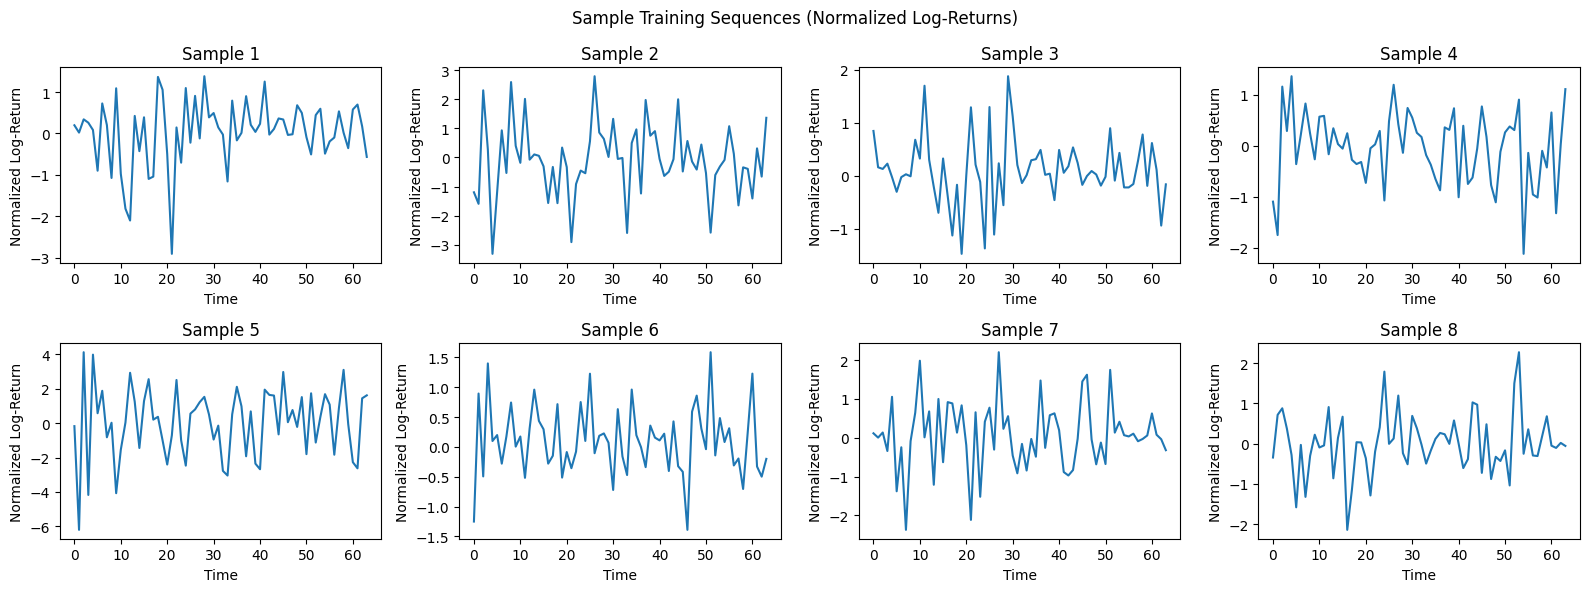

In [34]:
train_dataset, test_dataset, scaler_params = load_spy_data(seq_len=FM_CONFIG['seq_len'])

train_loader = DataLoader(train_dataset, batch_size=FM_CONFIG['batch_size'], shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=FM_CONFIG['batch_size'], shuffle=False)

# Visualize sample sequences
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for i, ax in enumerate(axes.flat):
    sample = train_dataset[i * 100].squeeze().numpy()
    ax.plot(sample)
    ax.set_title(f'Sample {i+1}')
    ax.set_xlabel('Time')
    ax.set_ylabel('Normalized Log-Return')
plt.suptitle('Sample Training Sequences (Normalized Log-Returns)')
plt.tight_layout()
plt.show()

## 3.3 Vector Field Network

Neural network that predicts the vector field $v_t(x)$ for Flow Matching.

In [35]:
class SinusoidalTimeEmbedding(nn.Module):
    """
    Sinusoidal time embedding for continuous time t ∈ [0, 1].
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = t[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings


class VectorFieldMLP(nn.Module):
    """
    MLP-based Vector Field Network for Flow Matching.

    Input: x_t (intermediate data) + t (time)
    Output: v_t(x_t) (predicted velocity/direction)
    """
    def __init__(self, input_dim, hidden_dim=256, num_layers=4, time_embed_dim=64):
        super().__init__()

        self.input_dim = input_dim
        self.time_embed_dim = time_embed_dim

        # Time embedding
        self.time_embed = nn.Sequential(
            SinusoidalTimeEmbedding(time_embed_dim),
            nn.Linear(time_embed_dim, hidden_dim),
            nn.SiLU(),
        )

        # Input projection
        self.input_proj = nn.Linear(input_dim, hidden_dim)

        # Main network
        layers = []
        for i in range(num_layers):
            layers.extend([
                nn.Linear(hidden_dim, hidden_dim),
                nn.LayerNorm(hidden_dim),
                nn.SiLU(),
                nn.Dropout(0.1),
            ])
        self.net = nn.Sequential(*layers)

        # Output projection
        self.output_proj = nn.Linear(hidden_dim, input_dim)

    def forward(self, x, t):
        """
        Forward pass.

        Args:
            x: [B, L, F] intermediate data
            t: [B] time values ∈ [0, 1]

        Returns:
            v: [B, L, F] predicted vector field
        """
        B, L, F = x.shape

        # Flatten spatial dimension
        x_flat = x.view(B, -1)  # [B, L*F]

        # Project input
        h = self.input_proj(x_flat)  # [B, hidden_dim]

        # Add time embedding
        t_emb = self.time_embed(t)  # [B, hidden_dim]
        h = h + t_emb

        # Main network
        h = self.net(h)

        # Output
        v = self.output_proj(h)  # [B, L*F]

        return v.view(B, L, F)


class VectorFieldTransformer(nn.Module):
    """
    Transformer-based Vector Field Network for better temporal modeling.
    """
    def __init__(self, seq_len, feature_dim=1, hidden_dim=128, num_heads=4, num_layers=4):
        super().__init__()

        self.seq_len = seq_len
        self.feature_dim = feature_dim

        # Positional encoding for sequence
        self.pos_embed = nn.Parameter(torch.randn(1, seq_len, hidden_dim) * 0.02)

        # Time embedding
        self.time_embed = nn.Sequential(
            SinusoidalTimeEmbedding(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
        )

        # Input projection
        self.input_proj = nn.Linear(feature_dim, hidden_dim)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=0.1,
            activation='gelu',
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Output projection
        self.output_proj = nn.Linear(hidden_dim, feature_dim)

    def forward(self, x, t):
        """
        Forward pass.

        Args:
            x: [B, L, F] intermediate data
            t: [B] time values ∈ [0, 1]

        Returns:
            v: [B, L, F] predicted vector field
        """
        B, L, F = x.shape

        # Project input
        h = self.input_proj(x)  # [B, L, hidden_dim]

        # Add positional embedding
        h = h + self.pos_embed[:, :L, :]

        # Add time embedding (broadcast across sequence)
        t_emb = self.time_embed(t)  # [B, hidden_dim]
        h = h + t_emb.unsqueeze(1)  # [B, L, hidden_dim]

        # Transformer
        h = self.transformer(h)

        # Output
        v = self.output_proj(h)  # [B, L, F]

        return v




In [36]:
mlp_model = VectorFieldMLP(
    input_dim=FM_CONFIG['seq_len'],
    hidden_dim=FM_CONFIG['hidden_dim'],
    num_layers=FM_CONFIG['num_layers']
).to(device)

# Transformer version
transformer_model = VectorFieldTransformer(
    seq_len=FM_CONFIG['seq_len'],
    hidden_dim=FM_CONFIG['hidden_dim'],
    num_layers=FM_CONFIG['num_layers']
).to(device)

# Test forward pass
test_x = torch.randn(4, FM_CONFIG['seq_len'], 1, device=device)
test_t = torch.rand(4, device=device)

mlp_out = mlp_model(test_x, test_t)
transformer_out = transformer_model(test_x, test_t)

print(f"MLP model parameters: {sum(p.numel() for p in mlp_model.parameters()):,}")
print(f"Transformer model parameters: {sum(p.numel() for p in transformer_model.parameters()):,}")
print(f"Input shape: {test_x.shape}, Output shape: {mlp_out.shape}")


MLP model parameters: 314,944
Transformer model parameters: 3,241,985
Input shape: torch.Size([4, 64, 1]), Output shape: torch.Size([4, 64, 1])


## 3.4 Flow Matching Training

Training the vector field network with the Flow Matching objective:
$$\mathcal{L}_{FM} = \mathbb{E}_{t, x_0, x_1} \|v_\theta(x_t, t) - (x_1 - x_0)\|^2$$

where $x_t = (1-t)x_0 + tx_1$ (linear interpolation / optimal transport path).

In [37]:
prices = spy.droplevel(0)['Adj Close'].values

NameError: name 'spy' is not defined

In [ ]:
flow_optimizer = torch.optim.Adam(flow_model.parameters(), lr=FM_CONFIG['learning_rate'])

flow_trainer = FlowMatchingTrainer(flow_model, flow_optimizer, device)

print(f"Model parameters: {sum(p.numel() for p in flow_model.parameters()):,}")


In [ ]:
# Train the Flow Matching model
# For demonstration, we use fewer epochs - increase for better results
DEMO_FM_EPOCHS = 50  # Change to FM_CONFIG['num_epochs'] for full training

flow_trainer.train(train_loader, test_loader, num_epochs=DEMO_FM_EPOCHS)
flow_trainer.plot_loss()

## 3.5 Step 3: Flow Matching Sampling (ODE Solver)

Generate samples by solving the ODE:
$$\frac{dx}{dt} = v_\theta(x, t)$$

from $t=0$ (noise) to $t=1$ (data) using numerical integration.

In [ ]:
class FlowMatchingSampler:
    """
    ODE Sampler for Flow Matching.

    Solves the ODE: dx/dt = v_θ(x, t)
    from t=0 (Gaussian noise) to t=1 (data distribution)

    Available solvers:
    - Euler: Simple first-order method
    - Heun: Second-order Runge-Kutta
    - RK4: Fourth-order Runge-Kutta (more accurate)
    """
    def __init__(self, model, device):
        self.model = model
        self.device = device

    @torch.no_grad()
    def euler_step(self, x, t, dt):
        """Euler method: x_{t+dt} = x_t + v(x_t, t) * dt"""
        v = self.model(x, t)
        return x + v * dt

    @torch.no_grad()
    def heun_step(self, x, t, dt):
        """Heun's method (2nd order RK): Predictor-Corrector"""
        # Predictor (Euler step)
        v1 = self.model(x, t)
        x_pred = x + v1 * dt

        # Corrector
        t_next = t + dt
        t_next = torch.clamp(t_next, 0, 1)
        v2 = self.model(x_pred, t_next)

        return x + (v1 + v2) * dt / 2

    @torch.no_grad()
    def rk4_step(self, x, t, dt):
        """Fourth-order Runge-Kutta (RK4)"""
        k1 = self.model(x, t)
        k2 = self.model(x + k1 * dt / 2, torch.clamp(t + dt / 2, 0, 1))
        k3 = self.model(x + k2 * dt / 2, torch.clamp(t + dt / 2, 0, 1))
        k4 = self.model(x + k3 * dt, torch.clamp(t + dt, 0, 1))

        return x + (k1 + 2*k2 + 2*k3 + k4) * dt / 6

    @torch.no_grad()
    def sample(self, n_samples, seq_len, feature_dim=1, n_steps=100, solver='euler', return_trajectory=False):
        """
        Generate samples using the trained vector field.

        Args:
            n_samples: Number of samples to generate
            seq_len: Sequence length
            feature_dim: Feature dimension
            n_steps: Number of ODE solver steps
            solver: 'euler', 'heun', or 'rk4'
            return_trajectory: Whether to return intermediate states

        Returns:
            Generated samples [n_samples, seq_len, feature_dim]
        """
        self.model.eval()

        # Start from standard Gaussian noise (t=0)
        x = torch.randn(n_samples, seq_len, feature_dim, device=self.device)

        # Time step size
        dt = 1.0 / n_steps

        # Choose solver
        if solver == 'euler':
            step_fn = self.euler_step
        elif solver == 'heun':
            step_fn = self.heun_step
        elif solver == 'rk4':
            step_fn = self.rk4_step
        else:
            raise ValueError(f"Unknown solver: {solver}")

        trajectory = [x.clone()] if return_trajectory else None

        # Integrate from t=0 to t=1
        for i in range(n_steps):
            t_value = i / n_steps
            t_tensor = torch.full((n_samples,), t_value, device=self.device)

            x = step_fn(x, t_tensor, dt)

            if return_trajectory and i % (n_steps // 10) == 0:
                trajectory.append(x.clone())

        if return_trajectory:
            trajectory.append(x.clone())
            return x, trajectory

        return x

    def compare_solvers(self, n_samples=10, seq_len=64, n_steps_list=[10, 25, 50, 100, 200]):
        """
        Compare different solvers and step counts.

        Demonstrates effect of number of solver steps on generation quality
        and computational cost.
        """
        results = {}

        print("Comparing ODE solvers...")
        for solver in ['euler', 'heun', 'rk4']:
            for n_steps in n_steps_list:
                start_time = torch.cuda.Event(enable_timing=True) if self.device == 'cuda' else None
                end_time = torch.cuda.Event(enable_timing=True) if self.device == 'cuda' else None

                if start_time:
                    start_time.record()

                samples = self.sample(n_samples, seq_len, n_steps=n_steps, solver=solver)

                if end_time:
                    end_time.record()
                    torch.cuda.synchronize()
                    time_ms = start_time.elapsed_time(end_time)
                else:
                    time_ms = 0

                results[(solver, n_steps)] = {
                    'samples': samples,
                    'time_ms': time_ms,
                    'std': samples.std().item()
                }

                print(f"  {solver:5s} ({n_steps:3d} steps): std={samples.std().item():.4f}, time={time_ms:.1f}ms")

        return results




In [ ]:
flow_sampler = FlowMatchingSampler(flow_model, device)

# Generate samples with different methods
print("\n📊 Comparing ODE Solver Effects:")
print("-" * 50)

# Quick comparison
for n_steps in [10, 50, 100]:
    samples = flow_sampler.sample(100, FM_CONFIG['seq_len'], n_steps=n_steps, solver='euler')
    print(f"Euler {n_steps:3d} steps: mean={samples.mean().item():.4f}, std={samples.std().item():.4f}")



## 3.6 Steps 4-5: Visualizing Generated Time Series

Display generated samples and compare with real data.

In [ ]:
# Generate samples for visualization
print("Generating samples for visualization...")
generated_samples = flow_sampler.sample(
    n_samples=500,
    seq_len=FM_CONFIG['seq_len'],
    n_steps=100,
    solver='euler'
)

# Get real test samples
real_test_samples = torch.stack([test_dataset[i] for i in range(min(500, len(test_dataset)))])

print(f"Generated samples shape: {generated_samples.shape}")
print(f"Real samples shape: {real_test_samples.shape}")


def denormalize(data, mean, std):
    """Restore data to original scale."""
    return data * std + mean


# Step 4: Display generated samples (normalized and denormalized)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Top row: Normalized samples
for i in range(4):
    sample_norm = generated_samples[i].squeeze().cpu().numpy()
    axes[0, i].plot(sample_norm, 'b-', alpha=0.8)
    axes[0, i].set_title(f'Generated Sample {i+1} (Normalized)')
    axes[0, i].set_xlabel('Time')
    axes[0, i].set_ylabel('Normalized Value')
    axes[0, i].grid(True, alpha=0.3)

# Bottom row: Denormalized samples
for i in range(4):
    sample_denorm = denormalize(
        generated_samples[i].squeeze().cpu().numpy(),
        scaler_params['mean'],
        scaler_params['std']
    )
    axes[1, i].plot(sample_denorm, 'g-', alpha=0.8)
    axes[1, i].set_title(f'Generated Sample {i+1} (Denormalized)')
    axes[1, i].set_xlabel('Time')
    axes[1, i].set_ylabel('Log-Return')
    axes[1, i].grid(True, alpha=0.3)

plt.suptitle('Step 4: Generated Time Series Samples')
plt.tight_layout()
save_fig('fm_generated_samples.png')
plt.show()


# Step 5: Qualitative comparison with real data
fig, axes = plt.subplots(3, 4, figsize=(16, 10))

# Row 1: Real samples from test set
for i in range(4):
    sample = real_test_samples[i].squeeze().cpu().numpy()
    axes[0, i].plot(sample, 'b-', alpha=0.8)
    axes[0, i].set_title(f'Real Sample {i+1}')
    axes[0, i].set_xlabel('Time')
    axes[0, i].grid(True, alpha=0.3)
axes[0, 0].set_ylabel('Normalized Value')

# Row 2: Generated samples
for i in range(4):
    sample = generated_samples[i].squeeze().cpu().numpy()
    axes[1, i].plot(sample, 'g-', alpha=0.8)
    axes[1, i].set_title(f'Generated Sample {i+1}')
    axes[1, i].set_xlabel('Time')
    axes[1, i].grid(True, alpha=0.3)
axes[1, 0].set_ylabel('Normalized Value')

# Row 3: Overlay comparison
for i in range(4):
    real = real_test_samples[i].squeeze().cpu().numpy()
    gen = generated_samples[i].squeeze().cpu().numpy()
    axes[2, i].plot(real, 'b-', alpha=0.6, label='Real')
    axes[2, i].plot(gen, 'g--', alpha=0.6, label='Generated')
    axes[2, i].set_title(f'Comparison {i+1}')
    axes[2, i].set_xlabel('Time')
    axes[2, i].legend()
    axes[2, i].grid(True, alpha=0.3)
axes[2, 0].set_ylabel('Normalized Value')

plt.suptitle('Step 5: Qualitative Comparison - Real vs Generated Time Series')
plt.tight_layout()
save_fig('fm_real_vs_gen.png')
plt.show()

print("✅ Visualization complete!")

## 3.7 Step 6: Distribution Comparison (Histogram/KDE)

Compare the distribution of log-returns between real and generated data.

In [ ]:
# Step 6: Distribution Comparison
print("📊 Step 6: Comparing Distributions of Real and Generated Data")
print("=" * 60)

# Flatten to get all individual values
real_values = real_test_samples.squeeze().cpu().numpy().flatten()
gen_values = generated_samples.squeeze().cpu().numpy().flatten()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram comparison
ax1 = axes[0, 0]
ax1.hist(real_values, bins=100, alpha=0.5, density=True, label='Real', color='blue')
ax1.hist(gen_values, bins=100, alpha=0.5, density=True, label='Generated', color='green')
ax1.set_xlabel('Normalized Log-Return')
ax1.set_ylabel('Density')
ax1.set_title('Histogram: Real vs Generated Distribution')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. KDE (Kernel Density Estimation)
ax2 = axes[0, 1]
from scipy.stats import gaussian_kde

real_kde = gaussian_kde(real_values)
gen_kde = gaussian_kde(gen_values)
x_range = np.linspace(-4, 4, 500)

ax2.plot(x_range, real_kde(x_range), 'b-', linewidth=2, label='Real')
ax2.plot(x_range, gen_kde(x_range), 'g--', linewidth=2, label='Generated')
ax2.fill_between(x_range, real_kde(x_range), alpha=0.3, color='blue')
ax2.fill_between(x_range, gen_kde(x_range), alpha=0.3, color='green')
ax2.set_xlabel('Normalized Log-Return')
ax2.set_ylabel('Density')
ax2.set_title('KDE: Real vs Generated Distribution')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Q-Q Plot
ax3 = axes[1, 0]
# Sort both distributions
real_sorted = np.sort(real_values)
gen_sorted = np.sort(gen_values)

# Subsample for plotting
n_points = min(1000, len(real_sorted), len(gen_sorted))
real_quantiles = np.percentile(real_values, np.linspace(1, 99, n_points))
gen_quantiles = np.percentile(gen_values, np.linspace(1, 99, n_points))

ax3.scatter(real_quantiles, gen_quantiles, alpha=0.5, s=10)
ax3.plot([real_quantiles.min(), real_quantiles.max()],
         [real_quantiles.min(), real_quantiles.max()], 'r--', linewidth=2)
ax3.set_xlabel('Real Quantiles')
ax3.set_ylabel('Generated Quantiles')
ax3.set_title('Q-Q Plot: Real vs Generated')
ax3.grid(True, alpha=0.3)

# 4. CDF Comparison
ax4 = axes[1, 1]
real_ecdf = np.arange(1, len(real_values) + 1) / len(real_values)
gen_ecdf = np.arange(1, len(gen_values) + 1) / len(gen_values)

ax4.plot(np.sort(real_values), real_ecdf, 'b-', label='Real', linewidth=1.5)
ax4.plot(np.sort(gen_values), gen_ecdf, 'g--', label='Generated', linewidth=1.5)
ax4.set_xlabel('Normalized Log-Return')
ax4.set_ylabel('Cumulative Probability')
ax4.set_title('Empirical CDF: Real vs Generated')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle('Step 6: Distribution Comparison - Real vs Generated Log-Returns', fontsize=14)
plt.tight_layout()
save_fig('fm_dist_comparison.png')
plt.show()

# Statistical tests
from scipy.stats import ks_2samp, wasserstein_distance

ks_stat, ks_pvalue = ks_2samp(real_values, gen_values)
w_distance = wasserstein_distance(real_values, gen_values)

print(f"\n📊 Distribution Similarity Metrics:")
print(f"  Kolmogorov-Smirnov Statistic: {ks_stat:.4f}")
print(f"  KS p-value: {ks_pvalue:.4e}")
print(f"  Wasserstein Distance: {w_distance:.4f}")
print(f"\n  Interpretation:")
print(f"  - Lower KS statistic = more similar distributions")
print(f"  - Lower Wasserstein distance = closer distributions")

## 3.8 Step 7: Basic Statistical Evaluation and Volatility

Compare mean, variance, and volatility between real and generated data.

In [ ]:
# Step 7: Basic Statistical Evaluation
print("📊 Step 7: Basic Statistical Evaluation and Volatility")
print("=" * 60)

def compute_statistics(data, name="Data"):
    """Compute and display statistics for time series data."""
    values = data.squeeze().cpu().numpy() if torch.is_tensor(data) else data.squeeze()

    # Overall statistics
    mean = np.mean(values)
    variance = np.var(values)
    std = np.std(values)
    skewness = stats.skew(values.flatten())
    kurtosis = stats.kurtosis(values.flatten())

    # Per-sequence volatility (standard deviation of each sequence)
    if len(values.shape) > 1:
        seq_volatilities = np.std(values, axis=1)
        avg_volatility = np.mean(seq_volatilities)
    else:
        avg_volatility = std

    print(f"\n{name}:")
    print(f"  Mean: {mean:.6f}")
    print(f"  Variance: {variance:.6f}")
    print(f"  Std (Volatility): {std:.6f}")
    print(f"  Avg Sequence Volatility: {avg_volatility:.6f}")
    print(f"  Skewness: {skewness:.4f}")
    print(f"  Kurtosis: {kurtosis:.4f}")

    return {
        'mean': mean,
        'variance': variance,
        'std': std,
        'volatility': avg_volatility,
        'skewness': skewness,
        'kurtosis': kurtosis
    }

# Compute statistics
real_stats = compute_statistics(real_test_samples, "Real Data")
gen_stats = compute_statistics(generated_samples, "Generated Data")

# Comparison visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Bar comparison of basic statistics
metrics = ['mean', 'variance', 'std']
real_vals = [real_stats[m] for m in metrics]
gen_vals = [gen_stats[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, real_vals, width, label='Real', color='blue', alpha=0.7)
axes[0].bar(x + width/2, gen_vals, width, label='Generated', color='green', alpha=0.7)
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Mean', 'Variance', 'Std Dev'])
axes[0].set_title('Basic Statistics Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Per-sequence volatility distribution
real_seq_vol = np.std(real_test_samples.squeeze().cpu().numpy(), axis=1)
gen_seq_vol = np.std(generated_samples.squeeze().cpu().numpy(), axis=1)

axes[1].hist(real_seq_vol, bins=30, alpha=0.5, density=True, label='Real', color='blue')
axes[1].hist(gen_seq_vol, bins=30, alpha=0.5, density=True, label='Generated', color='green')
axes[1].set_xlabel('Sequence Volatility (Std Dev)')
axes[1].set_ylabel('Density')
axes[1].set_title('Per-Sequence Volatility Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Higher-order moments comparison
moments = ['Skewness', 'Kurtosis']
real_moments = [real_stats['skewness'], real_stats['kurtosis']]
gen_moments = [gen_stats['skewness'], gen_stats['kurtosis']]

x = np.arange(len(moments))
axes[2].bar(x - width/2, real_moments, width, label='Real', color='blue', alpha=0.7)
axes[2].bar(x + width/2, gen_moments, width, label='Generated', color='green', alpha=0.7)
axes[2].set_xticks(x)
axes[2].set_xticklabels(moments)
axes[2].set_title('Higher-Order Moments Comparison')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=0, color='k', linestyle='-', linewidth=0.5)

plt.suptitle('Step 7: Statistical Evaluation - Real vs Generated', fontsize=14)
plt.tight_layout()
plt.show()

# Analysis
print("\n📊 Analysis:")
mean_error = abs(real_stats['mean'] - gen_stats['mean'])
var_error = abs(real_stats['variance'] - gen_stats['variance']) / real_stats['variance'] * 100
vol_error = abs(real_stats['volatility'] - gen_stats['volatility']) / real_stats['volatility'] * 100

print(f"  Mean Absolute Error: {mean_error:.6f}")
print(f"  Variance Relative Error: {var_error:.1f}%")
print(f"  Volatility Relative Error: {vol_error:.1f}%")

if vol_error < 10:
    print("  ✅ Model has correctly reproduced market volatility (error < 10%)")
elif vol_error < 25:
    print("  ⚠️ Model approximately captures volatility (10% < error < 25%)")
else:
    print("  ❌ Model needs improvement in volatility reproduction (error > 25%)")

## 3.9 Step 8: Advanced Structural and Temporal Evaluation

Compute advanced metrics:
- **Sliced Wasserstein Distance (SWD)**: Measures distributional similarity
- **Autocorrelation**: Measures temporal dependencies
- **Autocorrelation MSE**: How well the model captures temporal structure

In [ ]:

def sliced_wasserstein_distance(X, Y, n_projections=100):
    """
    Compute Sliced Wasserstein Distance between two distributions.

    SWD approximates the Wasserstein distance by projecting data onto
    random 1D directions and computing the 1D Wasserstein distance.

    This metric is useful because:
    - It's computationally efficient
    - It captures both marginal and structural differences
    - It works well for high-dimensional data (like time series)
    """
    # Flatten to 2D: [n_samples, seq_len]
    X = X.reshape(X.shape[0], -1)
    Y = Y.reshape(Y.shape[0], -1)

    dim = X.shape[1]

    # Generate random projections
    projections = np.random.randn(n_projections, dim)
    projections = projections / np.linalg.norm(projections, axis=1, keepdims=True)

    # Project data
    X_proj = X @ projections.T  # [n_samples, n_projections]
    Y_proj = Y @ projections.T

    # Compute 1D Wasserstein distance for each projection
    distances = []
    for i in range(n_projections):
        dist = wasserstein_distance(X_proj[:, i], Y_proj[:, i])
        distances.append(dist)

    return np.mean(distances)


def compute_autocorrelation(data, max_lag=20):
    """
    Compute autocorrelation for each sequence and average.

    Autocorrelation measures the correlation of a signal with
    a delayed copy of itself. It captures temporal dependencies.

    For financial data:
    - Positive AC at lag 1: momentum effect
    - Negative AC at lag 1: mean reversion
    - AC ≈ 0: efficient market (returns are roughly independent)
    """
    sequences = data.squeeze()
    if len(sequences.shape) == 1:
        sequences = sequences.reshape(1, -1)

    n_samples, seq_len = sequences.shape
    autocorrs = np.zeros((n_samples, max_lag))

    for i, seq in enumerate(sequences):
        # Normalize
        seq = seq - np.mean(seq)
        var = np.var(seq)
        if var > 1e-10:
            for lag in range(1, max_lag + 1):
                if lag < seq_len:
                    autocorrs[i, lag-1] = np.corrcoef(seq[:-lag], seq[lag:])[0, 1]

    return np.mean(autocorrs, axis=0), autocorrs



In [ ]:

# Compute metrics
real_data_np = real_test_samples.squeeze().cpu().numpy()
gen_data_np = generated_samples.squeeze().cpu().numpy()


In [ ]:
swd = sliced_wasserstein_distance(real_data_np, gen_data_np)
print(f"   SWD: {swd:.4f}")


In [ ]:
real_ac_mean, real_ac_all = compute_autocorrelation(real_data_np)
gen_ac_mean, gen_ac_all = compute_autocorrelation(gen_data_np)


In [ ]:
ac_mse = np.mean((real_ac_mean - gen_ac_mean) ** 2)
ac_mae = np.mean(np.abs(real_ac_mean - gen_ac_mean))

print(f"   Real AC(1): {real_ac_mean[0]:.4f}")
print(f"   Generated AC(1): {gen_ac_mean[0]:.4f}")
print(f"   Autocorrelation MSE: {ac_mse:.6f}")
print(f"   Autocorrelation MAE: {ac_mae:.6f}")
print(f"   Interpretation: Lower error = better temporal structure preservation")


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Autocorrelation comparison
ax1 = axes[0, 0]
lags = np.arange(1, len(real_ac_mean) + 1)
ax1.bar(lags - 0.2, real_ac_mean, 0.4, label='Real', color='blue', alpha=0.7)
ax1.bar(lags + 0.2, gen_ac_mean, 0.4, label='Generated', color='green', alpha=0.7)
ax1.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax1.set_xlabel('Lag')
ax1.set_ylabel('Autocorrelation')
ax1.set_title('Mean Autocorrelation by Lag')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Autocorrelation difference
ax2 = axes[0, 1]
ac_diff = gen_ac_mean - real_ac_mean
ax2.bar(lags, ac_diff, color=['red' if d < 0 else 'green' for d in ac_diff], alpha=0.7)
ax2.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Lag')
ax2.set_ylabel('Difference (Generated - Real)')
ax2.set_title('Autocorrelation Error by Lag')
ax2.grid(True, alpha=0.3)

# 3. Distribution of AC(1)
ax3 = axes[1, 0]
ax3.hist(real_ac_all[:, 0], bins=30, alpha=0.5, density=True, label='Real', color='blue')
ax3.hist(gen_ac_all[:, 0], bins=30, alpha=0.5, density=True, label='Generated', color='green')
ax3.set_xlabel('AC(1) Value')
ax3.set_ylabel('Density')
ax3.set_title('Distribution of Lag-1 Autocorrelation')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Summary metrics
ax4 = axes[1, 1]
metrics = ['SWD', 'AC MSE', 'AC MAE']
values = [swd, ac_mse * 100, ac_mae * 100]  # Scale for visualization

bars = ax4.bar(metrics, values, color=['purple', 'orange', 'red'], alpha=0.7)
ax4.set_ylabel('Metric Value')
ax4.set_title('Summary of Evaluation Metrics')
ax4.grid(True, alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars, [swd, ac_mse, ac_mae]):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.4f}', ha='center', va='bottom')

plt.suptitle('Step 8: Advanced Temporal and Structural Evaluation', fontsize=14)
plt.tight_layout()
save_fig('fm_autocorr.png')
plt.show()

print(f"  {'Sliced Wasserstein Dist':<25} {swd:<15.4f} {'Lower = better'}")
print(f"  {'Autocorrelation MSE':<25} {ac_mse:<15.6f} {'Lower = better'}")
print(f"  {'Autocorrelation MAE':<25} {ac_mae:<15.6f} {'Lower = better'}")

print(f"\n  What these metrics measure:")
print(f"  - SWD: Overall distributional similarity including shape")
print(f"  - AC MSE/MAE: How well temporal dependencies are preserved")
print(f"  - If AC error is low, the model has learned temporal patterns")

if ac_mse < 0.01:
    print(f"\n  ✅ Excellent temporal structure preservation!")
elif ac_mse < 0.05:
    print(f"\n  ⚠️ Good but imperfect temporal structure preservation")
else:
    print(f"\n  ❌ Model needs improvement in temporal dependency learning")

## 3.10 Complete Evaluation Report

Final summary of all evaluation metrics and model performance.

In [ ]:
# Complete Evaluation Report
print("=" * 70)
print("       FLOW MATCHING TIME SERIES GENERATION - EVALUATION REPORT")
print("=" * 70)

print("\n📋 MODEL CONFIGURATION")
print("-" * 70)
print(f"  Sequence Length: {FM_CONFIG['seq_len']}")
print(f"  Hidden Dimension: {FM_CONFIG['hidden_dim']}")
print(f"  Number of Layers: {FM_CONFIG['num_layers']}")
print(f"  Learning Rate: {FM_CONFIG['learning_rate']}")
print(f"  Batch Size: {FM_CONFIG['batch_size']}")
print(f"  Training Epochs: {DEMO_FM_EPOCHS}")

print("\n📊 TRAINING RESULTS")
print("-" * 70)
print(f"  Final Training Loss: {flow_trainer.train_loss_history[-1]:.5f}")
print(f"  Final Test Loss: {flow_trainer.test_loss_history[-1]:.5f}")
loss_gap = abs(flow_trainer.test_loss_history[-1] - flow_trainer.train_loss_history[-1])
print(f"  Train-Test Gap: {loss_gap:.5f}")

print("\n📊 STATISTICAL METRICS")
print("-" * 70)
print(f"  {'Metric':<30} {'Real':<15} {'Generated':<15} {'Error'}")
print(f"  {'-'*70}")
print(f"  {'Mean':<30} {real_stats['mean']:<15.6f} {gen_stats['mean']:<15.6f} {abs(real_stats['mean']-gen_stats['mean']):.6f}")
print(f"  {'Variance':<30} {real_stats['variance']:<15.6f} {gen_stats['variance']:<15.6f} {abs(real_stats['variance']-gen_stats['variance']):.6f}")
print(f"  {'Std (Volatility)':<30} {real_stats['std']:<15.6f} {gen_stats['std']:<15.6f} {abs(real_stats['std']-gen_stats['std']):.6f}")
print(f"  {'Skewness':<30} {real_stats['skewness']:<15.4f} {gen_stats['skewness']:<15.4f} {abs(real_stats['skewness']-gen_stats['skewness']):.4f}")
print(f"  {'Kurtosis':<30} {real_stats['kurtosis']:<15.4f} {gen_stats['kurtosis']:<15.4f} {abs(real_stats['kurtosis']-gen_stats['kurtosis']):.4f}")

print("\n📊 DISTRIBUTION METRICS")
print("-" * 70)
print(f"  Sliced Wasserstein Distance: {swd:.4f}")
print(f"  Wasserstein Distance (1D): {w_distance:.4f}")
print(f"  KS Statistic: {ks_stat:.4f}")

print("\n📊 TEMPORAL METRICS")
print("-" * 70)
print(f"  Autocorrelation MSE: {ac_mse:.6f}")
print(f"  Autocorrelation MAE: {ac_mae:.6f}")
print(f"  Real AC(1): {real_ac_mean[0]:.4f}")
print(f"  Generated AC(1): {gen_ac_mean[0]:.4f}")

print("\n📊 OVERALL ASSESSMENT")
print("-" * 70)

# Scoring
scores = {
    'Distribution': 100 * max(0, 1 - swd),
    'Volatility': 100 * max(0, 1 - abs(real_stats['std'] - gen_stats['std']) / real_stats['std']),
    'Temporal': 100 * max(0, 1 - ac_mse * 10),
    'Statistics': 100 * max(0, 1 - abs(real_stats['variance'] - gen_stats['variance']) / real_stats['variance'])
}

for metric, score in scores.items():
    bar = '█' * int(score / 5) + '░' * (20 - int(score / 5))
    print(f"  {metric:<15}: [{bar}] {score:.1f}%")

overall_score = np.mean(list(scores.values()))
print(f"\n  OVERALL SCORE: {overall_score:.1f}%")

if overall_score > 80:
    print("  ✅ Excellent model performance!")
elif overall_score > 60:
    print("  ⚠️ Good performance, room for improvement")
else:
    print("  ❌ Model needs more training or architecture tuning")

print("\n" + "=" * 70)
print("                          END OF REPORT")
print("=" * 70)

---
# Summary and Conclusion

## Part 1: DDPM & DDIM
- Implemented linear variance scheduler
- Created `perturb_input` function using reparameterization trick
- Built complete U-Net architecture with attention
- Implemented both DDPM (stochastic) and DDIM (deterministic) sampling

## Part 2: Stable Diffusion & DreamBooth
- Created DreamBoothDataset class with prior preservation support
- Implemented class image generation for preventing catastrophic forgetting
- Built training loop with LoRA for efficient fine-tuning
- Created inference pipeline for generating images with trained model

## Part 3: Flow Matching for Time Series
- Loaded and preprocessed SPY log-returns data
- Implemented Vector Field networks (MLP and Transformer)
- Created Flow Matching training with linear interpolation paths
- Built ODE solvers (Euler, Heun, RK4) for sampling
- Comprehensive evaluation with:
  - Distribution comparison (Histogram, KDE, Q-Q plots)
  - Basic statistics (Mean, Variance, Volatility)
  - Advanced metrics (Sliced Wasserstein Distance, Autocorrelation)

---

In [ ]:
# Save models for later use
print("Saving trained models...")

# Save Flow Matching model
torch.save({
    'model_state_dict': flow_model.state_dict(),
    'optimizer_state_dict': flow_optimizer.state_dict(),
    'train_loss': flow_trainer.train_loss_history,
    'test_loss': flow_trainer.test_loss_history,
    'config': FM_CONFIG,
    'scaler_params': scaler_params,
}, 'flow_matching_model.pt')
print("✅ Flow Matching model saved to 'flow_matching_model.pt'")

# Save DDPM model (if trained)
if len(trainer.loss_history) > 0:
    torch.save({
        'model_state_dict': ddpm_model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss_history': trainer.loss_history,
        'config': DDPM_CONFIG,
    }, 'ddpm_model.pt')
    print("DDPM model saved to 'ddpm_model.pt'")

print("\n🎉 All implementations complete!")

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define results folder path
results_folder = '/content/drive/My Drive/DGM_CA4_Results/'

# Create the folder if it doesn't exist
import os
os.makedirs(results_folder, exist_ok=True)

print(f"Results will be saved to: {results_folder}")